In [1]:
!pip install torch==2.5.1 \
    --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 85.5 MB/s  0:00:04:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 127.8 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 254.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 112.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 99.1 MB/s  0:00:03:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 219.5 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 208.5 MB/s  0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 112.4 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 99.9 MB/s  0:00:01:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 186.8 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7

In [1]:
!pip install seaborn

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
PyTorch CUDA: 12.1
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB MIG 1g.5gb


In [1]:
!gcc -O2 -Wall -Wextra uncompromised_nbti_rdd_solver-v2.c -o rd_model -lm

uncompromised_nbti_rdd_solver-v2.c: In function 'main':
uncompromised_nbti_rdd_solver-v2.c:314: warning: ignoring '#pragma omp parallel' []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/Warning-Options.html#index-Wno-unknown-pragmas-Wunknown-pragmas]8;;]
  314 |     #pragma omp parallel sections
uncompromised_nbti_rdd_solver-v2.c:316: warning: ignoring '#pragma omp section' []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/Warning-Options.html#index-Wno-unknown-pragmas-Wunknown-pragmas]8;;]
  316 |         #pragma omp section
uncompromised_nbti_rdd_solver-v2.c:319: warning: ignoring '#pragma omp section' []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/Warning-Options.html#index-Wno-unknown-pragmas-Wunknown-pragmas]8;;]
  319 |         #pragma omp section
uncompromised_nbti_rdd_solver-v2.c:322: warning: ignoring '#pragma omp section' []8;;https://gcc.gnu.org/onlinedocs/gcc-15.2.0/gcc/Warning-Options.html#index-Wno-unknown-pragmas-Wunknown-pragmas]8;;]
  322 |      

In [12]:
!gcc -O3 -fopenmp -o pure_nbti_rd_solver.c -lm

/srv/conda/envs/notebook/bin/../lib/gcc/x86_64-conda-linux-gnu/15.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: /srv/conda/envs/notebook/bin/../x86_64-conda-linux-gnu/sysroot/lib/../lib/Scrt1.o: in function `_start':
(.text+0x1b): undefined reference to `main'
collect2: error: ld returned 1 exit status


In [11]:
!./rdd_solver


[INITIALIZING] Running Model 3 (T = 125.0 C, Eox = 4.00 MV/cm) -> rdd_model_III_defect_assisted.csv

[INITIALIZING] Running Model 4 (T = 125.0 C, Eox = 4.00 MV/cm) -> rdd_model_IV_full_rdd.csv

[INITIALIZING] Running Model 2 (T = 125.0 C, Eox = 4.00 MV/cm) -> rdd_model_II_direct_dimer.csv

[INITIALIZING] Running Model 1 (T = 125.0 C, Eox = 4.00 MV/cm) -> rdd_model_I_atomic.csv

[SUCCESS] All 4 Models calculated self-consistently and printed to CSVs.


Loaded Model I: Atomic H successfully.
Loaded Model II: Direct Dimer successfully.
Loaded Model III: Defect-Assisted successfully.
Loaded Model IV: Full RDD successfully.


/tmp/ipykernel_1682/3036323930.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


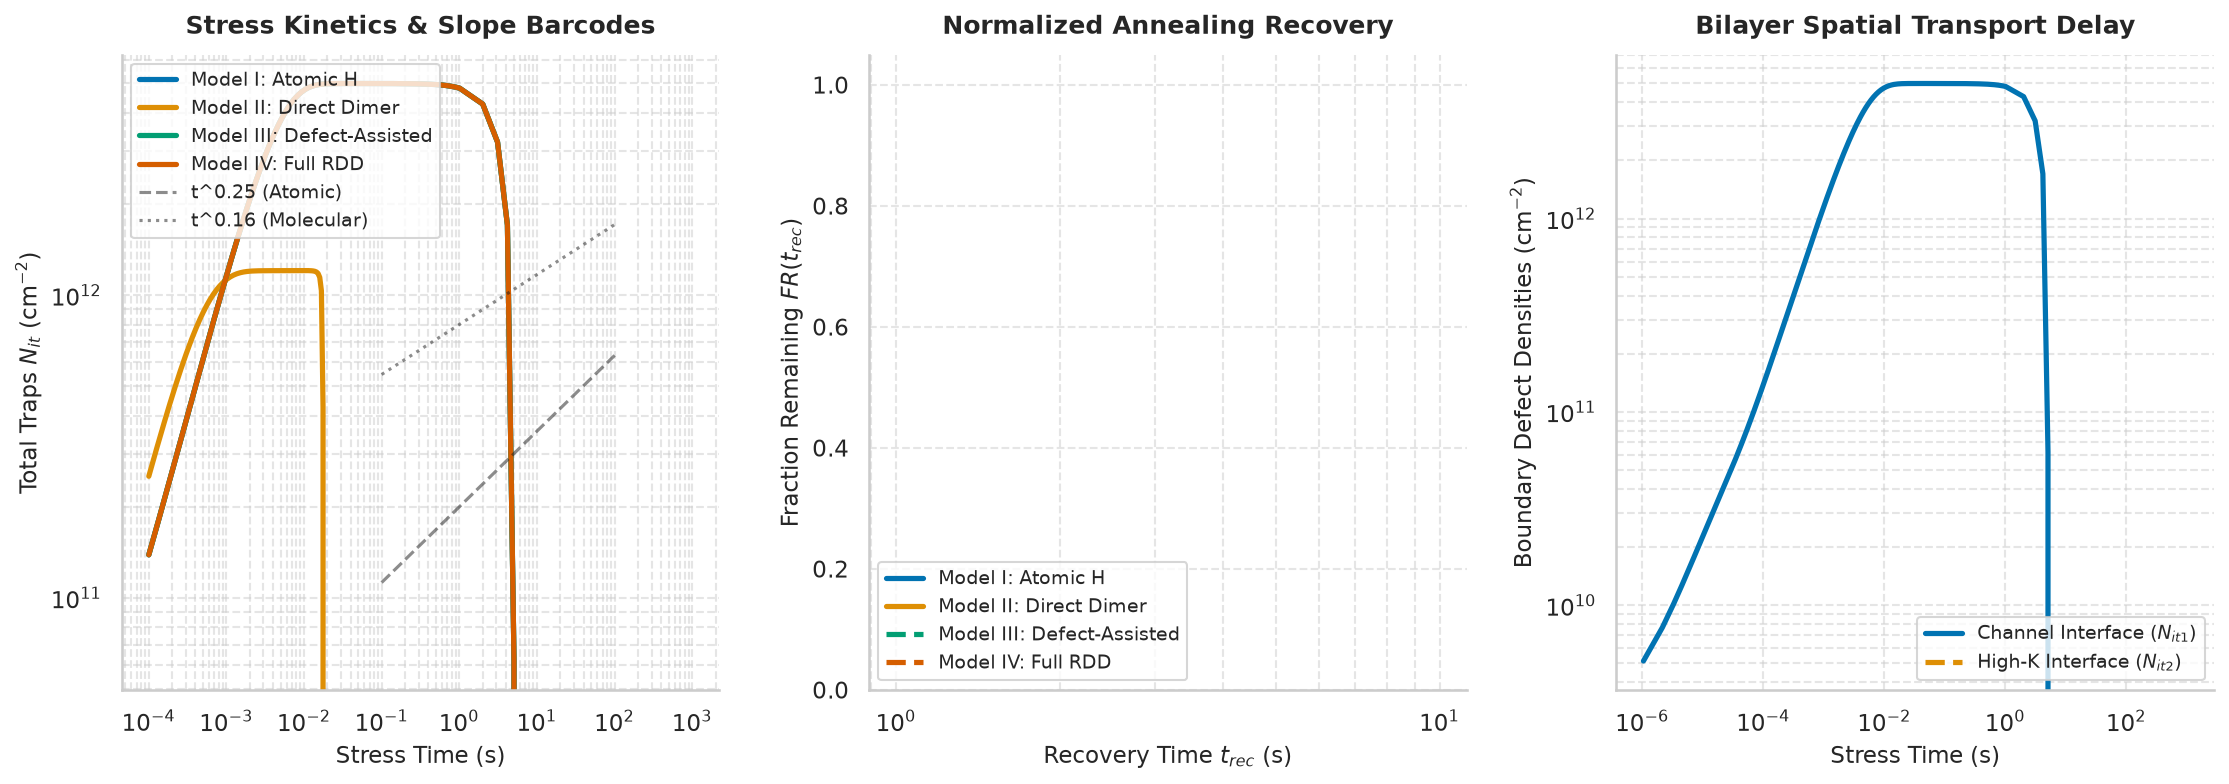

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set publication quality styling
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150

# Load datasets
models = {
    'Model I: Atomic H': 'rdd_model_I_atomic.csv',
    'Model II: Direct Dimer': 'rdd_model_II_direct_dimer.csv',
    'Model III: Defect-Assisted': 'rdd_model_III_defect_assisted.csv',
    'Model IV: Full RDD': 'rdd_model_IV_full_rdd.csv'
}

dfs = {}
for name, path in models.items():
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        print(f"Loaded {name} successfully.")

# Create a 3-panel professional dashboard
fig = plt.figure(figsize=(18, 5.5))
gs = fig.add_gridspec(1, 3, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0]) # Plot 1
ax2 = fig.add_subplot(gs[0, 1]) # Plot 2
ax3 = fig.add_subplot(gs[0, 2]) # Plot 3

# =====================================================================
# PLOT 1: STRESS POWER-LAW SLOPES (LOG-LOG)
# =====================================================================
for name, df in dfs.items():
    df_stress = df[df['time'] <= 1000.0]
    # Filter t > 0 to prevent log(0)
    df_stress = df_stress[df_stress['time'] > 1e-4]
    
    # Total traps: Nit1 + Nit2
    Nit_total = df_stress['Nit1'] + df_stress['Nit2']
    ax1.loglog(df_stress['time'], Nit_total, label=name, linewidth=2.5)

# Add reference slopes
t_ref = np.logspace(-1, 2, 20)
ax1.loglog(t_ref, 2.0e11 * (t_ref)**0.25, 'k--', alpha=0.5, label='t^0.25 (Atomic)')
ax1.loglog(t_ref, 8.0e11 * (t_ref)**0.165, 'k:', alpha=0.5, label='t^0.16 (Molecular)')

ax1.set_title('Stress Kinetics & Slope Barcodes', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Stress Time (s)', fontsize=11)
ax1.set_ylabel('Total Traps $N_{it}$ (cm$^{-2}$)', fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=9, loc='upper left')

# =====================================================================
# PLOT 2: FRACTION REMAINING DURING RECOVERY (SEMI-LOG)
# =====================================================================
for name, df in dfs.items():
    df_rec = df[df['time'] >= 1000.0].copy()
    df_rec['t_rec'] = df_rec['time'] - 1000.0
    
    # Value at end of stress
    Nit_stress_end = df[df['time'] < 1000.0].iloc[-1]
    Nit_0 = Nit_stress_end['Nit1'] + Nit_stress_end['Nit2']
    
    df_rec['FR'] = (df_rec['Nit1'] + df_rec['Nit2']) / Nit_0
    df_rec = df_rec[df_rec['t_rec'] > 1e-2] # Filter short times for log-scale
    
    linestyle = '--' if 'Lock-in' in name or 'Assisted' in name or 'RDD' in name else '-'
    ax2.semilogx(df_rec['t_rec'], df_rec['FR'], label=name, linewidth=2.5, linestyle=linestyle)

ax2.set_title('Normalized Annealing Recovery', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Recovery Time $t_{rec}$ (s)', fontsize=11)
ax2.set_ylabel('Fraction Remaining $FR(t_{rec})$', fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=9, loc='lower left')

# =====================================================================
# PLOT 3: SPATIAL COUPLING DELAY (MODEL III vs IV)
# =====================================================================
if 'Model III: Defect-Assisted' in dfs:
    df_m3 = dfs['Model III: Defect-Assisted']
    df_m3_stress = df_m3[(df_m3['time'] <= 1000.0) & (df_m3['time'] > 1e-6)]
    
    ax3.loglog(df_m3_stress['time'], df_m3_stress['Nit1'], label='Channel Interface ($N_{it1}$)', color='#0173b2', linewidth=2.5)
    ax3.loglog(df_m3_stress['time'], df_m3_stress['Nit2'], label='High-K Interface ($N_{it2}$)', color='#de8f05', linewidth=2.5, linestyle='--')

ax3.set_title('Bilayer Spatial Transport Delay', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Stress Time (s)', fontsize=11)
ax3.set_ylabel('Boundary Defect Densities (cm$^{-2}$)', fontsize=11)
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.legend(fontsize=9, loc='lower right')

sns.despine()
plt.tight_layout()
plt.savefig('uncompromised_nbti_4_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
!gcc -O3 -fopenmp -o rd_v3_solver pure_nbti_rd_solver.c -lm export OMP_NUM_THREADS=3


pure_nbti_rd_solver.c: In function 'run_pure_rd_simulation':
pure_nbti_rd_solver.c:88:42: error: stray '\' in program
   88 |     FILE *fp = fopen(config.output_file, \"w\");
      |                                          ^
pure_nbti_rd_solver.c:88:43: warning: missing terminating " character
   88 |     FILE *fp = fopen(config.output_file, \"w\");
      |                                           ^
pure_nbti_rd_solver.c:88:43: error: missing terminating " character
   88 |     FILE *fp = fopen(config.output_file, \"w\");
      |                                           ^~~~~~
pure_nbti_rd_solver.c:89:5: error: expected expression before 'if'
   89 |     if (!fp) {
      |     ^~
pure_nbti_rd_solver.c:262:1: error: expected ',' or ';' before '}' token
  262 | }
      | ^
pure_nbti_rd_solver.c:287:1: error: expected declaration or statement at end of input
  287 | }
      | ^


In [37]:
!gcc -O3 -fopenmp -o rd_solver pure_nbti_rd_solver.c -lm

In [38]:
!./rd_solver


[INITIALIZING] Running Pure RD Model 1 (T = 125.0 C) -> rd_model_I_atomic.csv

[INITIALIZING] Running Pure RD Model 2 (T = 125.0 C) -> rd_model_II_direct_dimer.csv

[INITIALIZING] Running Pure RD Model 3 (T = 125.0 C) -> rd_model_III_defect_assisted.csv

[SUCCESS] All 3 Pure RD Models calculated self-consistently and printed to CSVs.


Successfully loaded 1. Basic RD (Atomic H) (2223 simulation points).
Successfully loaded 2. RD with H2 Dimerization (2223 simulation points).
Successfully loaded 3. Defect-Assisted Dimerization (2223 simulation points).


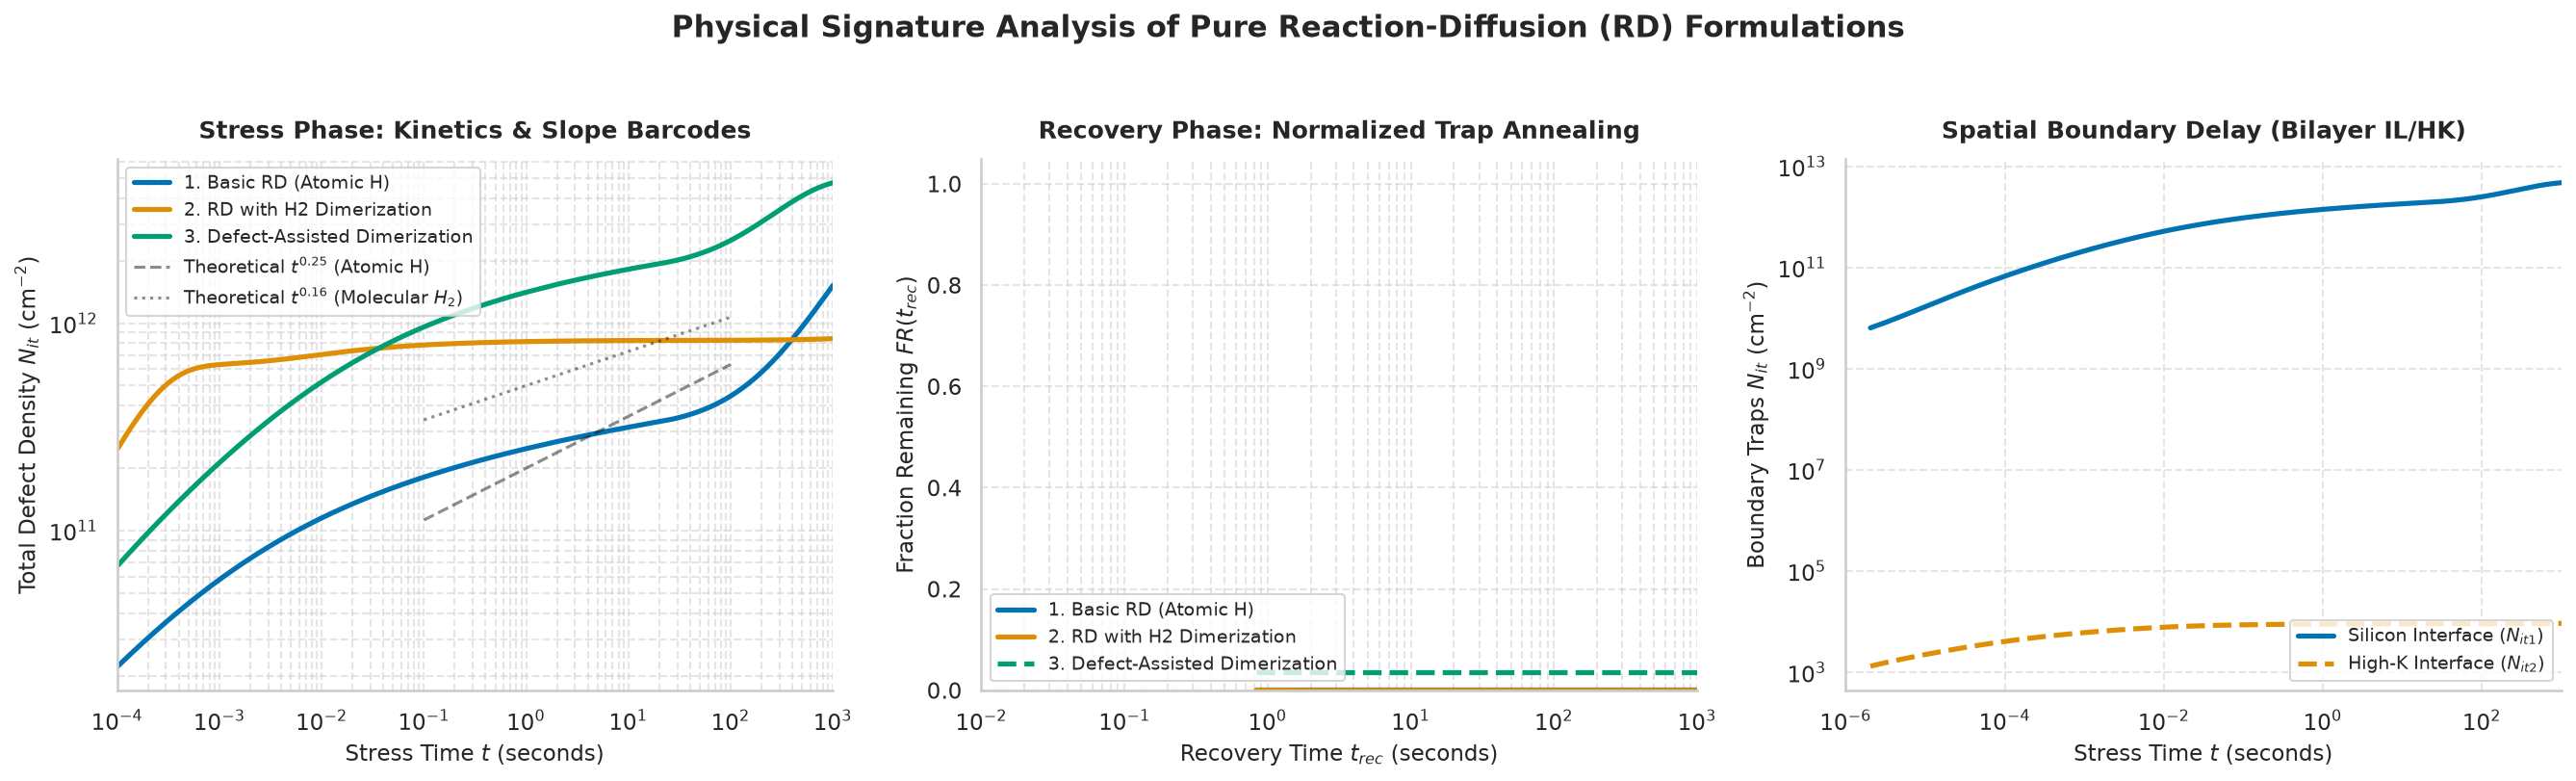

In [39]:
# %% [markdown]
# # Diagnostic Plotting of Pure Reaction-Diffusion (RD) Models
# This cell imports the required visualization packages and sets up standard 
# publication-grade styling as seen in IEEE transactions papers.

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional IEEE/Seaborn theme
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150  # Render high-resolution figures

# %% [markdown]
# ### Cell 1: Load Raw Datasets
# Verify that the stable C CSV files are present in your current working directory.

# %%
# Define your pure RD models mapping to their CSV files
files = {
    '1. Basic RD (Atomic H)': 'rd_model_I_atomic.csv',
    '2. RD with H2 Dimerization': 'rd_model_II_direct_dimer.csv',
    '3. Defect-Assisted Dimerization': 'rd_model_III_defect_assisted.csv'
}

dfs = {}
for name, filename in files.items():
    if os.path.exists(filename):
        dfs[name] = pd.read_csv(filename)
        print(f"Successfully loaded {name} ({len(dfs[name])} simulation points).")
    else:
        print(f"Warning: {filename} not found in this folder. Double check path!")

# %% [markdown]
# ### Cell 2: Generate the 3-Panel Diagnostic Dashboard
# This cell plots the exact physical fingerprints of the three models side-by-side:
# 1. **Plot A (Stress Phase)**: Log-Log plot showing the slope barcodes ($n \approx 0.25$ vs $n \approx 0.16$).
# 2. **Plot B (Recovery Phase)**: Semi-Log plot showing the Fraction Remaining ($FR$) and the molecular lock-in.
# 3. **Plot C (Bilayer Delay)**: Highlighting the transport lag between Interface 1 and Interface 2.

# %%
# Initialize a wide canvas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

fig.suptitle('Physical Signature Analysis of Pure Reaction-Diffusion (RD) Formulations',
             fontsize=15, fontweight='bold', y=0.98)

# ----------------------------------------------------------------------
# PANEL 1: STRESS POWER-LAW KINETICS (LOG-LOG)
# ----------------------------------------------------------------------
for name, df in dfs.items():
    # Filter stress phase data (t <= 1000s)
    df_stress = df[(df['time'] <= 1000.0) & (df['time'] > 1e-4)].copy()
    
    # Total traps = Nit1 (interface) + Nit2 (HK bulk trap, if applicable)
    df_stress['Nit_total'] = df_stress['Nit1'] + df_stress['Nit2']
    
    ax1.loglog(df_stress['time'], df_stress['Nit_total'], label=name, linewidth=2.5)

# Add reference slope lines (Theoretical guidelines)
t_ref = np.logspace(-1, 2, 20)
# Reference line for 1/4 slope (Atomic)
ax1.loglog(t_ref, 2.0e11 * (t_ref)**0.25, 'k--', alpha=0.5, label=r'Theoretical $t^{0.25}$ (Atomic H)')
# Reference line for 1/6 slope (Molecular)
ax1.loglog(t_ref, 5.0e11 * (t_ref)**0.165, 'k:', alpha=0.5, label=r'Theoretical $t^{0.16}$ (Molecular $H_2$)')

ax1.set_title('Stress Phase: Kinetics & Slope Barcodes', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Stress Time $t$ (seconds)', fontsize=11)
ax1.set_ylabel(r'Total Defect Density $N_{it}$ (cm$^{-2}$)', fontsize=11)
ax1.set_xlim(1e-4, 1000.0)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=9, loc='upper left')

# ----------------------------------------------------------------------
# PANEL 2: FRACTION REMAINING DURING RECOVERY (SEMI-LOG)
# ----------------------------------------------------------------------
for name, df in dfs.items():
    # Filter recovery phase data (t >= 1000s)
    df_rec = df[df['time'] >= 1000.0].copy()
    df_rec['t_rec'] = df_rec['time'] - 1000.0
    
    # Get initial trap state at the end of the stress phase (t = 1000s)
    stress_end_row = df[df['time'] < 1000.0].iloc[-1]
    Nit_0 = stress_end_row['Nit1'] + stress_end_row['Nit2']
    
    # Calculate Fraction Remaining (FR)
    df_rec['FR'] = (df_rec['Nit1'] + df_rec['Nit2']) / Nit_0
    
    # Filter t_rec > 0 for semi-log axis
    df_rec = df_rec[df_rec['t_rec'] > 1e-2]
    
    linestyle = '--' if 'Defect-Assisted' in name else '-'
    ax2.semilogx(df_rec['t_rec'], df_rec['FR'], label=name, linewidth=2.5, linestyle=linestyle)

ax2.set_title('Recovery Phase: Normalized Trap Annealing', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Recovery Time $t_{rec}$ (seconds)', fontsize=11)
ax2.set_ylabel(r'Fraction Remaining $FR(t_{rec})$', fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.set_xlim(1e-2, 1000.0)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=9, loc='lower left')

# ----------------------------------------------------------------------
# PANEL 3: BILAYER SPATIAL TRANSPORT DELAY (LOG-LOG)
# ----------------------------------------------------------------------
if '3. Defect-Assisted Dimerization' in dfs:
    df_da = dfs['3. Defect-Assisted Dimerization']
    df_da_stress = df_da[(df_da['time'] <= 1000.0) & (df_da['time'] > 1e-6)]
    
    ax3.loglog(df_da_stress['time'], df_da_stress['Nit1'], label=r'Silicon Interface ($N_{it1}$)', color='#0173b2', linewidth=2.5)
    ax3.loglog(df_da_stress['time'], df_da_stress['Nit2'], label=r'High-K Interface ($N_{it2}$)', color='#de8f05', linewidth=2.5, linestyle='--')

ax3.set_title('Spatial Boundary Delay (Bilayer IL/HK)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Stress Time $t$ (seconds)', fontsize=11)
ax3.set_ylabel(r'Boundary Traps $N_{it}$ (cm$^{-2}$)', fontsize=11)
ax3.set_xlim(1e-6, 1000.0)
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.legend(fontsize=9, loc='lower right')

# Final formatting adjustments
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('reaction_comparison_pure_rd.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
/* ============================================================
 * RD NUMERICAL SOLVER
 *
 * Thomas algorithm for a tridiagonal linear system:
 *
 *     a[i] x[i-1]
 *   + b[i] x[i]
 *   + c[i] x[i+1]
 *   = d[i]
 *
 * This will be used by the fully implicit
 * backward-Euler diffusion solver.
 * ============================================================ */

void rd_thomas_solver(
    double a[],
    double b[],
    double c[],
    double d[],
    double x[],
    int n)
{
    double cp[301];
    double dp[301];

    /* --------------------------------------------------------
     * Forward elimination
     * -------------------------------------------------------- */

    cp[0] = c[0] / b[0];
    dp[0] = d[0] / b[0];

    for (int i = 1; i < n; i++)
    {
        double denominator =
            b[i] - a[i] * cp[i - 1];

        if (fabs(denominator) < 1.0e-30)
        {
            printf(
                "ERROR: Thomas solver near-singular "
                "at row %d\n",
                i
            );

            return;
        }

        if (i < n - 1)
            cp[i] = c[i] / denominator;

        dp[i] =
            (d[i] - a[i] * dp[i - 1])
            / denominator;
    }

    /* --------------------------------------------------------
     * Back substitution
     * -------------------------------------------------------- */

    x[n - 1] =
        dp[n - 1];

    for (int i = n - 2; i >= 0; i--)
    {
        x[i] =
            dp[i] - cp[i] * x[i + 1];
    }
}


/* ============================================================
 * SIMPLE VERIFICATION
 *
 * Matrix:
 *
 * [ 2  -1   0 ] [x0]   [1]
 * [-1   2  -1 ] [x1] = [0]
 * [ 0  -1   2 ] [x2]   [1]
 *
 * Expected:
 *
 * x0 = 1
 * x1 = 1
 * x2 = 1
 * ============================================================ */

void test_rd_thomas_solver(void)
{
    double a[3] = {
         0.0,
        -1.0,
        -1.0
    };

    double b[3] = {
         2.0,
         2.0,
         2.0
    };

    double c[3] = {
        -1.0,
        -1.0,
         0.0
    };

    double d[3] = {
        1.0,
        0.0,
        1.0
    };

    double x[3] = {
        0.0,
        0.0,
        0.0
    };

    rd_thomas_solver(
        a,
        b,
        c,
        d,
        x,
        3
    );

    printf("RD Thomas solver test\n");
    printf("---------------------\n");

    printf("x[0] = %.12f\n", x[0]);
    printf("x[1] = %.12f\n", x[1]);
    printf("x[2] = %.12f\n", x[2]);

    if (fabs(x[0] - 1.0) < 1.0e-12 &&
        fabs(x[1] - 1.0) < 1.0e-12 &&
        fabs(x[2] - 1.0) < 1.0e-12)
    {
        printf("\nThomas solver: PASS\n");
    }
    else
    {
        printf("\nThomas solver: FAIL\n");
    }
}


/* Run test */

test_rd_thomas_solver();

SyntaxError: invalid syntax (2493504288.py, line 1)

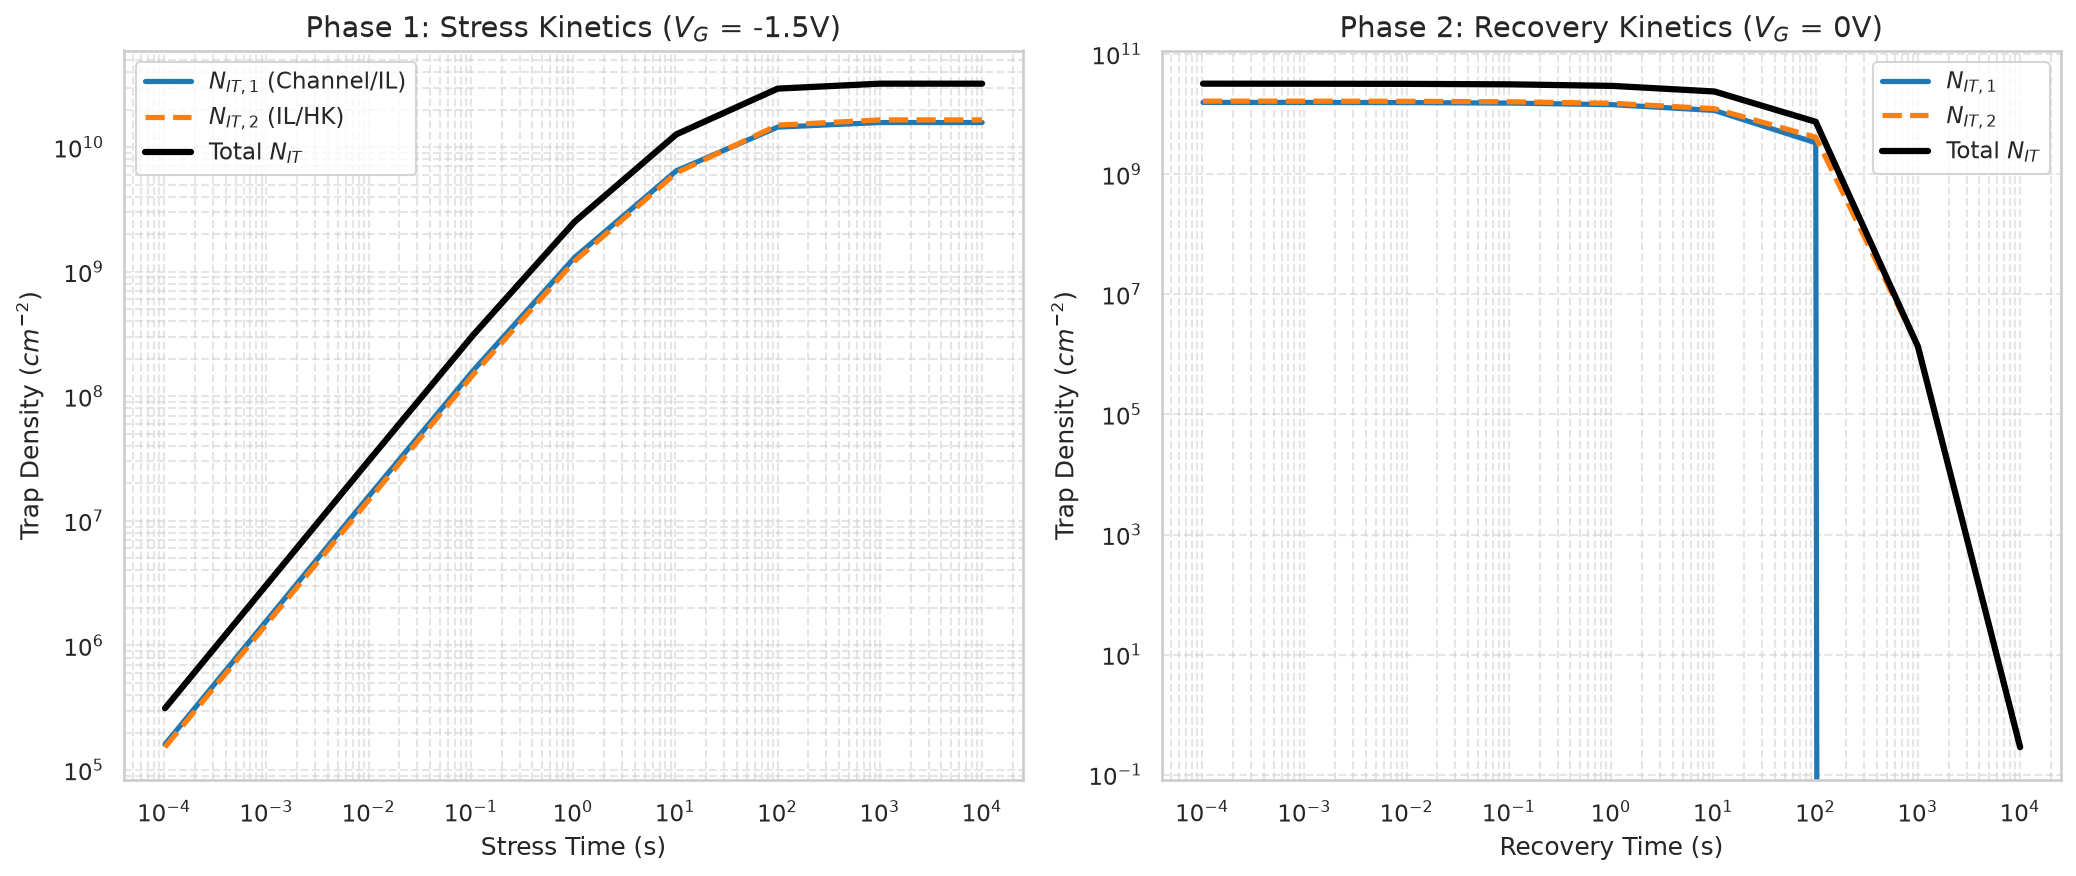

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('rd_results.csv')
except FileNotFoundError:
    print("Error: 'rd_results.csv' not found. Run the C program first.")
    exit()

stress_df = df[df['Phase'] == 'Stress']
recovery_df = df[df['Phase'] == 'Recovery']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Phase 1: Stress
ax1.plot(stress_df['Time'], stress_df['NIT1'], label=r'$N_{IT,1}$ (Channel/IL)', linewidth=2.5, color='#1f77b4')
ax1.plot(stress_df['Time'], stress_df['NIT2'], label=r'$N_{IT,2}$ (IL/HK)', linewidth=2.5, linestyle='--', color='#ff7f0e')
ax1.plot(stress_df['Time'], stress_df['Total_NIT'], label='Total $N_{IT}$', color='black', linewidth=3)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Phase 1: Stress Kinetics ($V_G$ = -1.5V)', fontsize=14)
ax1.set_xlabel('Stress Time (s)', fontsize=12)
ax1.set_ylabel(r'Trap Density ($cm^{-2}$)', fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=11)

# Plot Phase 2: Recovery
ax2.plot(recovery_df['Time'], recovery_df['NIT1'], label=r'$N_{IT,1}$', linewidth=2.5, color='#1f77b4')
ax2.plot(recovery_df['Time'], recovery_df['NIT2'], label=r'$N_{IT,2}$', linewidth=2.5, linestyle='--', color='#ff7f0e')
ax2.plot(recovery_df['Time'], recovery_df['Total_NIT'], label='Total $N_{IT}$', color='black', linewidth=3)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Phase 2: Recovery Kinetics ($V_G$ = 0V)', fontsize=14)
ax2.set_xlabel('Recovery Time (s)', fontsize=12)
ax2.set_ylabel(r'Trap Density ($cm^{-2}$)', fontsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()



STRESS-TIME EXPONENT ANALYSIS

Expected long-time RD exponent:
    n = 1/6 = 0.166667

Local exponent:
Time midpoint (s) n = dlogN/dlogt 
----------------------------------------
3.21410e-04      0.999997        
3.18418e-03      0.999973        
3.23217e-02      0.999729        
3.28085e-01      0.997302        
3.25000e+00      0.975556        
3.21944e+01      0.857567        
3.18917e+02      0.646095        
3.23720e+03      0.500653        
3.28595e+04      0.420954        
3.25505e+05      0.374627        
3.20530e+06      0.347061        
3.16677e+07      0.323178        


----------------------------------------------------------------------
Latest local exponent = 0.323178
Target 1/6            = 0.166667
Difference from 1/6    = 0.156511
Relative difference    = 93.91%


Latest 5-point log-log fitted exponent = 0.365338
Difference from 1/6 = 0.198671


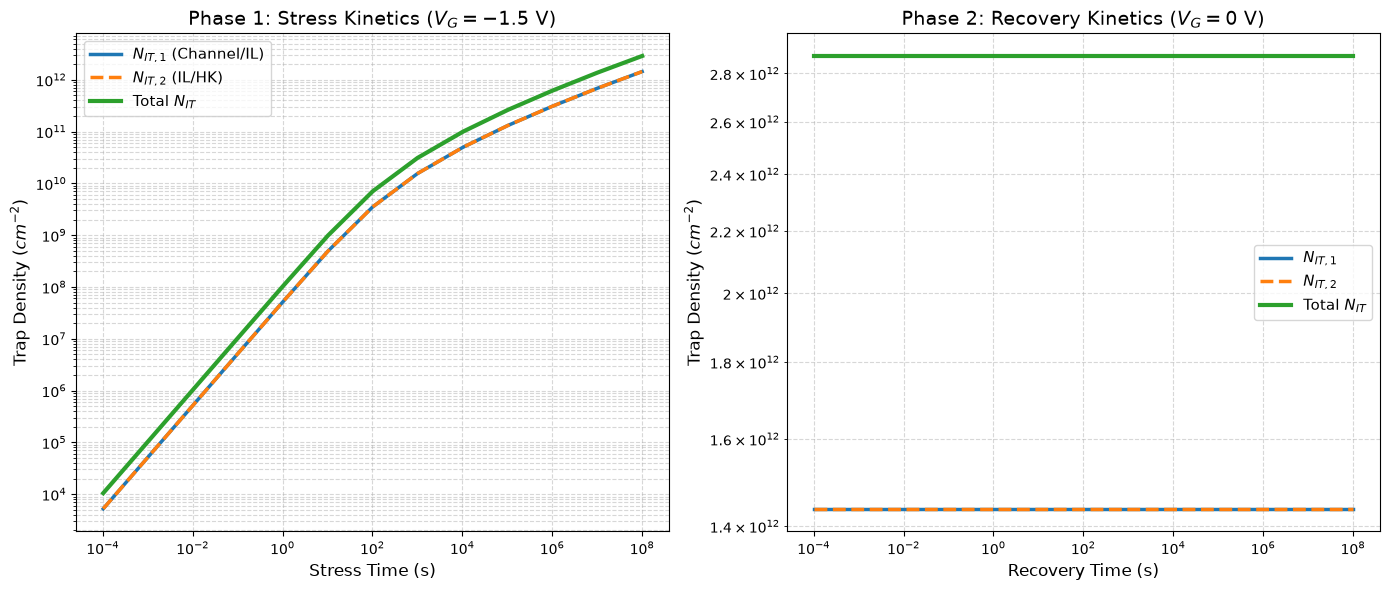

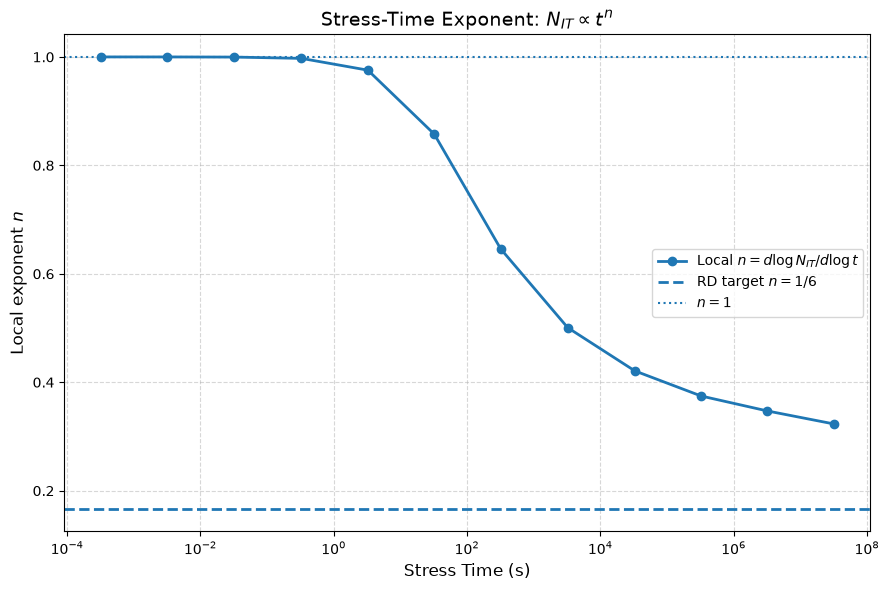

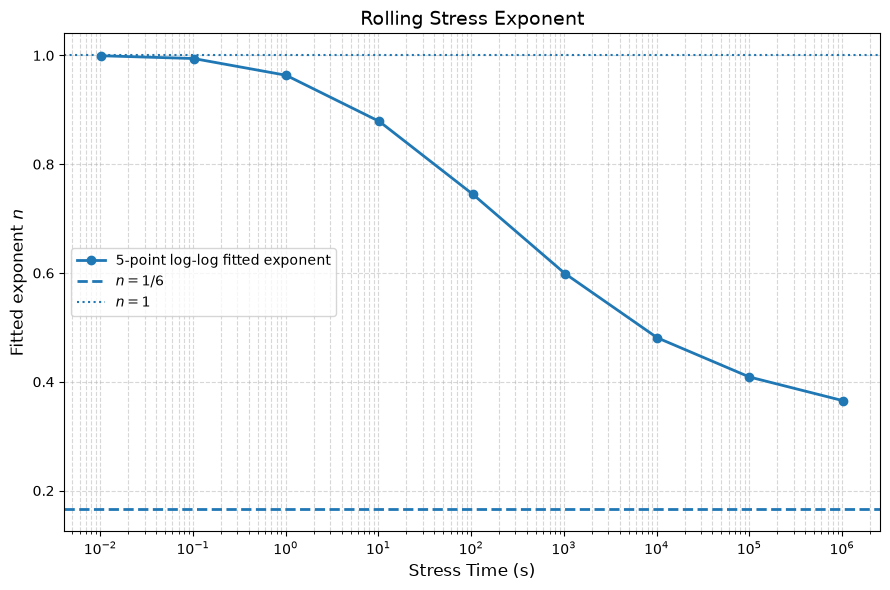



LONG-TIME POWER-LAW CHECK
Last 3 points: n = 0.335055
Last 4 points: n = 0.348140
Last 5 points: n = 0.365338

Target:
n = 1/6 = 0.166667


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================

try:
    df = pd.read_csv("rd_results.csv")
except FileNotFoundError:
    print("Error: 'rd_results.csv' not found.")
    raise SystemExit

stress_df = df[df["Phase"] == "Stress"].copy()
recovery_df = df[df["Phase"] == "Recovery"].copy()

# Make sure data are sorted
stress_df = stress_df.sort_values("Time")
recovery_df = recovery_df.sort_values("Time")


# ============================================================
# FUNCTION: LOCAL LOG-LOG EXPONENT
#
# n = d(log N) / d(log t)
# ============================================================

def local_exponent(time, density):

    time = np.asarray(time, dtype=float)
    density = np.asarray(density, dtype=float)

    log_t = np.log10(time)
    log_N = np.log10(density)

    n = np.diff(log_N) / np.diff(log_t)

    # Geometric midpoint of each interval
    t_mid = np.sqrt(time[:-1] * time[1:])

    return t_mid, n


# ============================================================
# FUNCTION: ROLLING LOG-LOG FIT
#
# Fits:
#
# log10(N) = n log10(t) + b
#
# over a moving window.
# ============================================================

def rolling_exponent(time, density, window=5):

    time = np.asarray(time, dtype=float)
    density = np.asarray(density, dtype=float)

    log_t = np.log10(time)
    log_N = np.log10(density)

    centers = []
    exponents = []

    if len(time) < window:
        return np.array([]), np.array([])

    for i in range(len(time) - window + 1):

        x = log_t[i:i + window]
        y = log_N[i:i + window]

        slope, intercept = np.polyfit(x, y, 1)

        centers.append(
            np.sqrt(time[i] * time[i + window - 1])
        )

        exponents.append(slope)

    return np.array(centers), np.array(exponents)


# ============================================================
# CALCULATE LOCAL EXPONENT FOR TOTAL NIT
# ============================================================

t_local, n_local = local_exponent(
    stress_df["Time"],
    stress_df["Total_NIT"]
)


# ============================================================
# CALCULATE LOCAL EXPONENTS FOR EACH INTERFACE
# ============================================================

t_local_1, n_local_1 = local_exponent(
    stress_df["Time"],
    stress_df["NIT1"]
)

t_local_2, n_local_2 = local_exponent(
    stress_df["Time"],
    stress_df["NIT2"]
)


# ============================================================
# ROLLING EXPONENT
# ============================================================

# Use 5 points per log-log fit.
#
# If your simulation has many more points, you can increase
# this to 7 or 9 for a smoother estimate.

t_roll, n_roll = rolling_exponent(
    stress_df["Time"],
    stress_df["Total_NIT"],
    window=5
)


# ============================================================
# PRINT LOCAL EXPONENTS
# ============================================================

print("\n")
print("=" * 70)
print("STRESS-TIME EXPONENT ANALYSIS")
print("=" * 70)

print("\nExpected long-time RD exponent:")
print("    n = 1/6 = {:.6f}".format(1.0 / 6.0))

print("\nLocal exponent:")
print(
    "{:<16} {:<16}".format(
        "Time midpoint (s)",
        "n = dlogN/dlogt"
    )
)

print("-" * 40)

for t, n in zip(t_local, n_local):

    print(
        "{:<16.5e} {:<16.6f}".format(
            t,
            n
        )
    )


# ============================================================
# LAST-POINT ANALYSIS
# ============================================================

if len(n_local) > 0:

    last_n = n_local[-1]

    print("\n")
    print("-" * 70)

    print(
        "Latest local exponent = {:.6f}".format(last_n)
    )

    print(
        "Target 1/6            = {:.6f}".format(1.0 / 6.0)
    )

    print(
        "Difference from 1/6    = {:.6f}".format(
            last_n - 1.0 / 6.0
        )
    )

    print(
        "Relative difference    = {:.2f}%".format(
            100.0 *
            abs(last_n - 1.0 / 6.0)
            / (1.0 / 6.0)
        )
    )


# ============================================================
# LAST ROLLING FIT
# ============================================================

if len(n_roll) > 0:

    last_roll = n_roll[-1]

    print("\n")
    print(
        "Latest {}-point log-log fitted exponent = {:.6f}".format(
            5,
            last_roll
        )
    )

    print(
        "Difference from 1/6 = {:.6f}".format(
            last_roll - 1.0 / 6.0
        )
    )


# ============================================================
# PLOT 1:
# ORIGINAL STRESS + RECOVERY KINETICS
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ------------------------------------------------------------
# Stress
# ------------------------------------------------------------

ax1.plot(
    stress_df["Time"],
    stress_df["NIT1"],
    label=r"$N_{IT,1}$ (Channel/IL)",
    linewidth=2.5
)

ax1.plot(
    stress_df["Time"],
    stress_df["NIT2"],
    label=r"$N_{IT,2}$ (IL/HK)",
    linewidth=2.5,
    linestyle="--"
)

ax1.plot(
    stress_df["Time"],
    stress_df["Total_NIT"],
    label=r"Total $N_{IT}$",
    linewidth=3
)

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_title(
    r"Phase 1: Stress Kinetics ($V_G=-1.5$ V)",
    fontsize=14
)

ax1.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax1.set_ylabel(
    r"Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax1.legend(fontsize=11)


# ------------------------------------------------------------
# Recovery
# ------------------------------------------------------------

ax2.plot(
    recovery_df["Time"],
    recovery_df["NIT1"],
    label=r"$N_{IT,1}$",
    linewidth=2.5
)

ax2.plot(
    recovery_df["Time"],
    recovery_df["NIT2"],
    label=r"$N_{IT,2}$",
    linewidth=2.5,
    linestyle="--"
)

ax2.plot(
    recovery_df["Time"],
    recovery_df["Total_NIT"],
    label=r"Total $N_{IT}$",
    linewidth=3
)

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_title(
    r"Phase 2: Recovery Kinetics ($V_G=0$ V)",
    fontsize=14
)

ax2.set_xlabel(
    "Recovery Time (s)",
    fontsize=12
)

ax2.set_ylabel(
    r"Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax2.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2:
# LOCAL STRESS EXPONENT
# ============================================================

plt.figure(figsize=(9, 6))

plt.semilogx(
    t_local,
    n_local,
    marker="o",
    linewidth=2,
    label=r"Local $n=d\log N_{IT}/d\log t$"
)

# Reference n = 1/6
plt.axhline(
    1.0 / 6.0,
    linestyle="--",
    linewidth=2,
    label=r"RD target $n=1/6$"
)

# Also show n = 1
plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    label=r"$n=1$"
)

plt.xlabel(
    "Stress Time (s)",
    fontsize=12
)

plt.ylabel(
    r"Local exponent $n$",
    fontsize=12
)

plt.title(
    r"Stress-Time Exponent: $N_{IT}\propto t^n$",
    fontsize=14
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3:
# ROLLING LOG-LOG EXPONENT
# ============================================================

plt.figure(figsize=(9, 6))

if len(t_roll) > 0:

    plt.semilogx(
        t_roll,
        n_roll,
        marker="o",
        linewidth=2,
        label="5-point log-log fitted exponent"
    )

plt.axhline(
    1.0 / 6.0,
    linestyle="--",
    linewidth=2,
    label=r"$n=1/6$"
)

plt.axhline(
    1.0,
    linestyle=":",
    linewidth=1.5,
    label=r"$n=1$"
)

plt.xlabel(
    "Stress Time (s)",
    fontsize=12
)

plt.ylabel(
    r"Fitted exponent $n$",
    fontsize=12
)

plt.title(
    r"Rolling Stress Exponent",
    fontsize=14
)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL:
# DIRECT LOG-LOG FIT OF THE LAST FEW POINTS
# ============================================================

print("\n")
print("=" * 70)
print("LONG-TIME POWER-LAW CHECK")
print("=" * 70)

for number_of_points in [3, 4, 5]:

    if len(stress_df) >= number_of_points:

        tail = stress_df.tail(number_of_points)

        x = np.log10(
            tail["Time"].values
        )

        y = np.log10(
            tail["Total_NIT"].values
        )

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        print(
            "Last {:d} points: n = {:.6f}".format(
                number_of_points,
                slope
            )
        )

print("\nTarget:")
print("n = 1/6 = {:.6f}".format(1.0 / 6.0))

print("=" * 70)

Successfully loaded: nr_results_65C.csv
Successfully loaded: nr_results_85C.csv
Successfully loaded: nr_results_125C.csv
Successfully loaded: nr_results_150C.csv


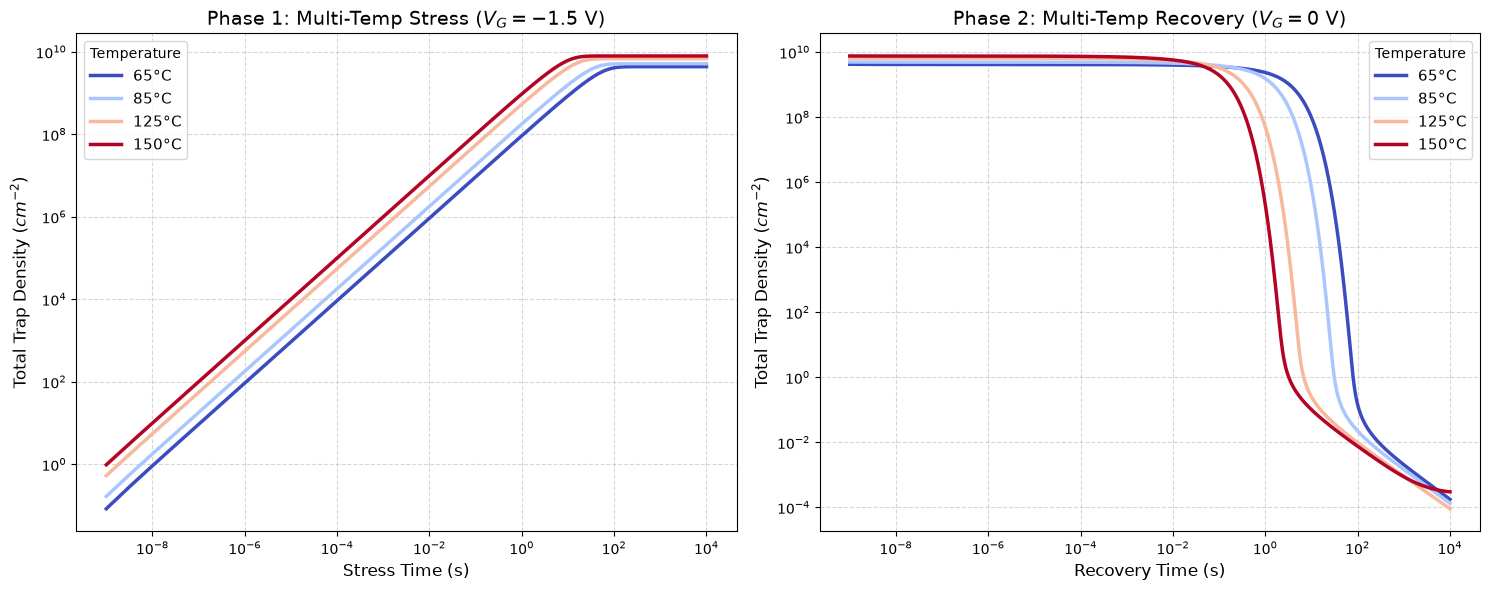

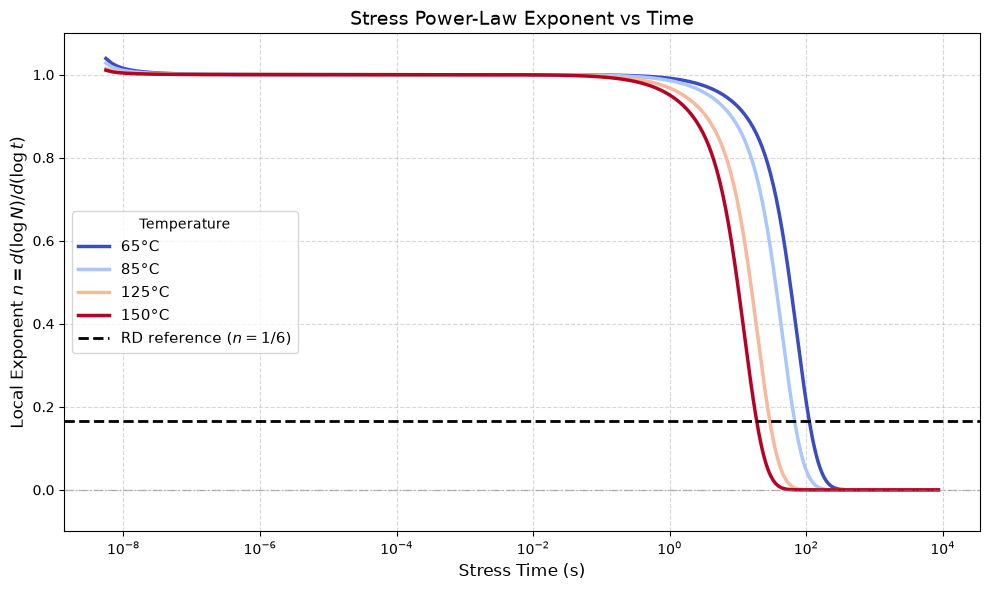

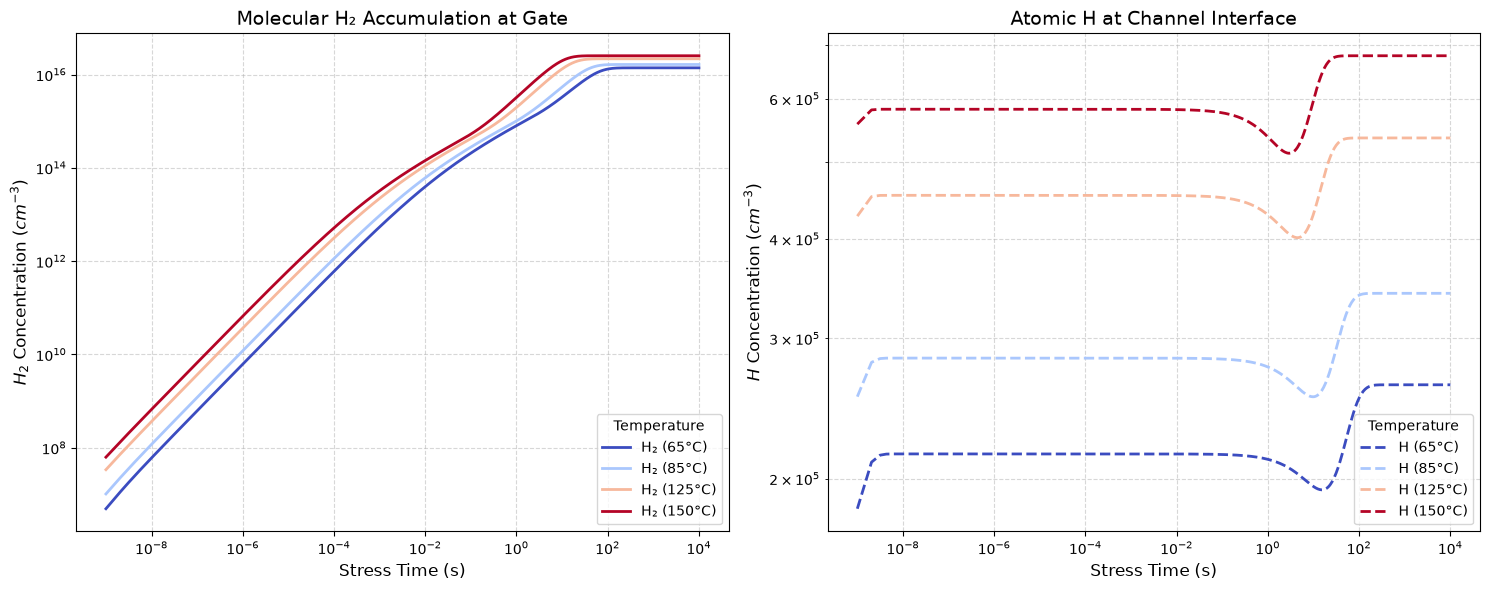

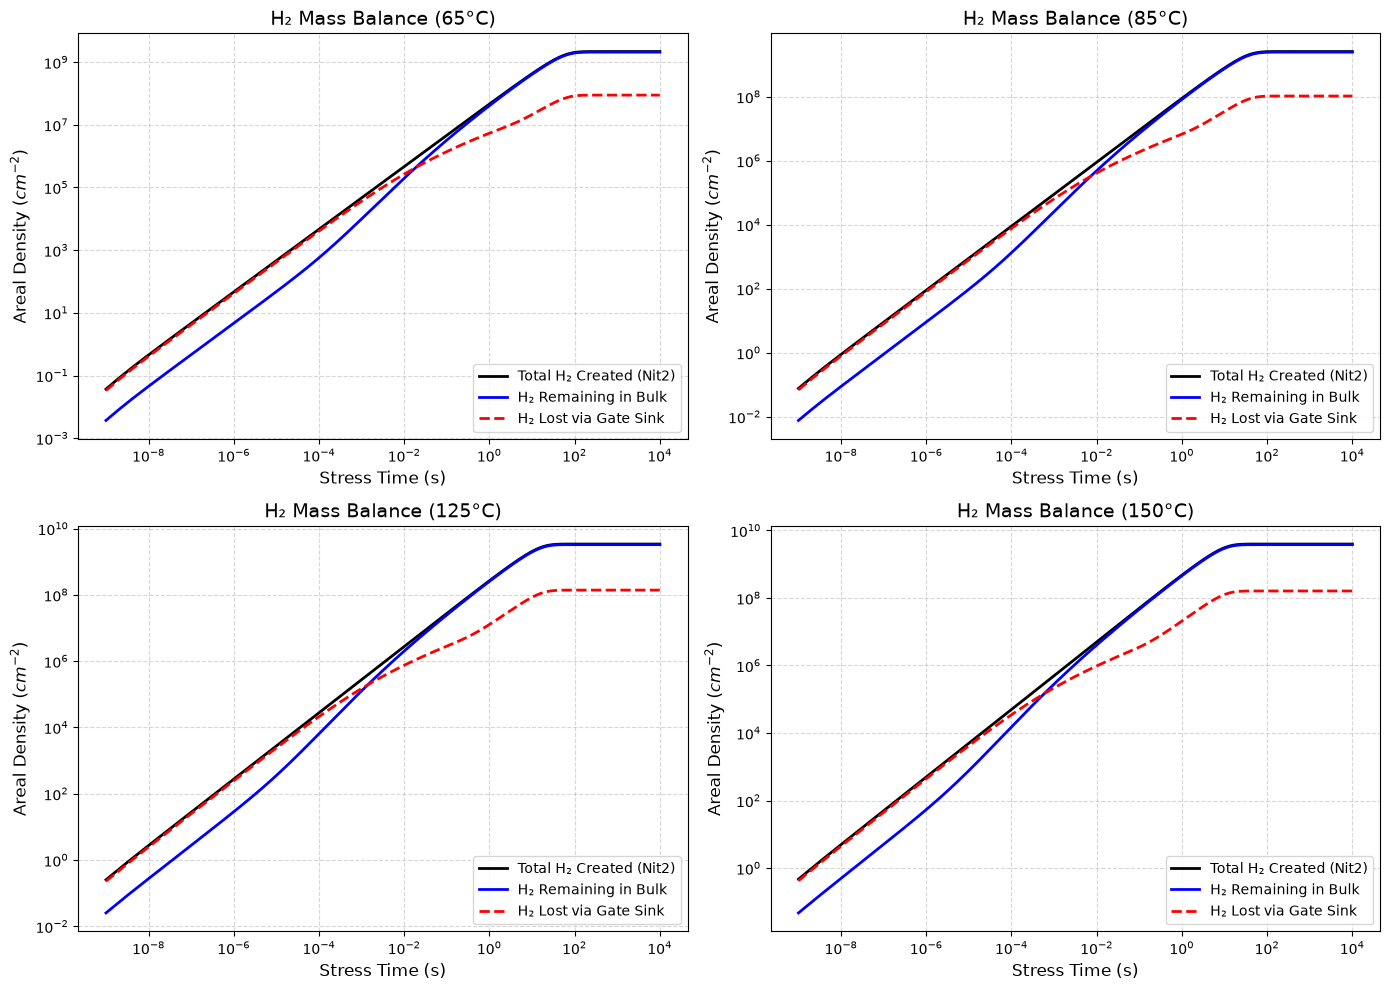


POWER-LAW EXPONENT SUMMARY
 65°C : long-time n = 0.0803 ± 0.1629 (RD reference = 0.1667)
 85°C : long-time n = 0.0320 ± 0.0804 (RD reference = 0.1667)
125°C : long-time n = 0.0018 ± 0.0066 (RD reference = 0.1667)
150°C : long-time n = 0.0001 ± 0.0006 (RD reference = 0.1667)


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ====================================================================
# CONFIGURATION
# ====================================================================

temperatures = [65, 85, 125, 150]

# Your current C code produces:
# nr_results_25C.csv
# nr_results_85C.csv
# nr_results_125C.csv
# nr_results_150C.csv
file_prefix = "nr_results_"

# Window size for local power-law fitting.
# Must be an odd number.
POWERLAW_WINDOW = 9

# ====================================================================
# LOAD DATA
# ====================================================================

data_dict = {}

for T in temperatures:

    filename = f"{file_prefix}{T}C.csv"

    try:
        df = pd.read_csv(filename)

        # Total trap density
        if "Total_NIT" not in df.columns:
            df["Total_NIT"] = df["Nit1"] + df["Nit2"]

        # Make sure time is numeric
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

        # Remove invalid rows
        df = df.dropna(subset=["Time", "Nit1", "Nit2"])

        data_dict[T] = df

        print(f"Successfully loaded: {filename}")

    except FileNotFoundError:
        print(f"WARNING: Could not find {filename}. Skipping...")

    except Exception as e:
        print(f"ERROR loading {filename}: {e}")


if not data_dict:
    print("Error: No data files found.")
    raise SystemExit


# ====================================================================
# COLORS
# ====================================================================

colors = cm.coolwarm(
    np.linspace(0, 1, len(temperatures))
)


# ====================================================================
# HELPER FUNCTION
# LOCAL POWER-LAW EXPONENT
#
# N(t) ~ t^n
#
# Therefore:
#
# log10(N) = n log10(t) + constant
#
# n = slope of log10(N) vs log10(t)
# ====================================================================

def calculate_local_exponent(time, density, window=9):

    time = np.asarray(time, dtype=float)
    density = np.asarray(density, dtype=float)

    # Only positive values can be placed on log scale
    valid = (
        np.isfinite(time)
        & np.isfinite(density)
        & (time > 0)
        & (density > 0)
    )

    time = time[valid]
    density = density[valid]

    if len(time) < window:
        return np.array([]), np.array([])

    # Sort by time
    order = np.argsort(time)

    time = time[order]
    density = density[order]

    log_t = np.log10(time)
    log_N = np.log10(density)

    t_local = []
    n_local = []

    half = window // 2

    for i in range(half, len(time) - half):

        x = log_t[i-half:i+half+1]
        y = log_N[i-half:i+half+1]

        # Linear fit:
        #
        # log10(N) = n*log10(t) + intercept
        #
        slope, intercept = np.polyfit(x, y, 1)

        t_local.append(time[i])
        n_local.append(slope)

    return np.asarray(t_local), np.asarray(n_local)


# ====================================================================
# PLOT 1
# STRESS + RECOVERY TRAP KINETICS
# ====================================================================

fig1, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    df = data_dict[T]

    # ------------------------------------------------------------
    # STRESS
    # ------------------------------------------------------------

    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if not stress_df.empty:

        valid = (
            (stress_df["Time"] > 0)
            & (stress_df["Total_NIT"] > 0)
        )

        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Total_NIT"],
            label=f"{T}°C",
            color=colors[i],
            linewidth=2.5
        )

    # ------------------------------------------------------------
    # RECOVERY
    # ------------------------------------------------------------

    recovery_df = (
        df[df["Phase"] == "Recovery"]
        .sort_values("Time")
    )

    if not recovery_df.empty:

        valid = (
            (recovery_df["Time"] > 0)
            & (recovery_df["Total_NIT"] > 0)
        )

        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Total_NIT"],
            label=f"{T}°C",
            color=colors[i],
            linewidth=2.5
        )


# ====================================================================
# STRESS AXIS
# ====================================================================

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_title(
    r"Phase 1: Multi-Temp Stress ($V_G=-1.5$ V)",
    fontsize=14
)

ax1.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax1.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax1.legend(
    title="Temperature",
    fontsize=11
)


# ====================================================================
# RECOVERY AXIS
# ====================================================================

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_title(
    r"Phase 2: Multi-Temp Recovery ($V_G=0$ V)",
    fontsize=14
)

ax2.set_xlabel(
    "Recovery Time (s)",
    fontsize=12
)

ax2.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax2.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax2.legend(
    title="Temperature",
    fontsize=11
)

fig1.tight_layout()


# ====================================================================
# PLOT 2
# LOCAL POWER-LAW EXPONENT
#
# N(t) ~ t^n
#
# n(t) = d(log N) / d(log t)
#
# We estimate this using a local linear regression rather than
# taking point-to-point numerical differences.
# ====================================================================

fig2, ax3 = plt.subplots(
    figsize=(10, 6)
)


for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    stress_df = (
        data_dict[T]
        [data_dict[T]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if stress_df.empty:
        continue

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(t_mid) == 0:
        continue

    ax3.plot(
        t_mid,
        n_local,
        label=f"{T}°C",
        color=colors[i],
        linewidth=2.5
    )


# ====================================================================
# REFERENCE LINES
# ====================================================================

# RD long-time reference
ax3.axhline(
    1.0 / 6.0,
    linestyle="--",
    linewidth=2,
    color="black",
    label=r"RD reference ($n=1/6$)"
)

# Zero exponent
ax3.axhline(
    0.0,
    linestyle="-.",
    linewidth=1,
    color="grey",
    alpha=0.5
)


# ====================================================================
# POWER-LAW FORMATTING
# ====================================================================

ax3.set_xscale("log")

ax3.set_title(
    "Stress Power-Law Exponent vs Time",
    fontsize=14
)

ax3.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax3.set_ylabel(
    r"Local Exponent $n=d(\log N)/d(\log t)$",
    fontsize=12
)

ax3.set_ylim(
    -0.1,
    1.1
)

ax3.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax3.legend(
    title="Temperature",
    fontsize=11
)

fig2.tight_layout()


# ====================================================================
# PLOT 3
# HYDROGEN DYNAMICS
# ====================================================================

fig3, (ax4, ax5) = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    df = data_dict[T]

    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if stress_df.empty:
        continue

    # ------------------------------------------------------------
    # MOLECULAR H2
    # ------------------------------------------------------------

    valid_H2 = (
        (stress_df["Time"] > 0)
        & (stress_df["Mol_H2"] > 1e-10)
    )

    ax4.plot(
        stress_df.loc[valid_H2, "Time"],
        stress_df.loc[valid_H2, "Mol_H2"],
        label=f"H₂ ({T}°C)",
        color=colors[i],
        linewidth=2
    )

    # ------------------------------------------------------------
    # ATOMIC H
    # ------------------------------------------------------------

    valid_H0 = (
        (stress_df["Time"] > 0)
        & (stress_df["Atomic_H0"] > 1e-10)
    )

    ax5.plot(
        stress_df.loc[valid_H0, "Time"],
        stress_df.loc[valid_H0, "Atomic_H0"],
        label=f"H ({T}°C)",
        color=colors[i],
        linestyle="--",
        linewidth=2
    )


# ====================================================================
# H2 PLOT
# ====================================================================

ax4.set_xscale("log")
ax4.set_yscale("log")

ax4.set_title(
    "Molecular H₂ Accumulation at Gate",
    fontsize=14
)

ax4.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax4.set_ylabel(
    r"$H_2$ Concentration ($cm^{-3}$)",
    fontsize=12
)

ax4.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax4.legend(
    title="Temperature",
    fontsize=10,
    loc="lower right"
)


# ====================================================================
# ATOMIC H PLOT
# ====================================================================

ax5.set_xscale("log")
ax5.set_yscale("log")

ax5.set_title(
    "Atomic H at Channel Interface",
    fontsize=14
)

ax5.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax5.set_ylabel(
    r"$H$ Concentration ($cm^{-3}$)",
    fontsize=12
)

ax5.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax5.legend(
    title="Temperature",
    fontsize=10,
    loc="lower right"
)


fig3.tight_layout()


# ====================================================================
# PLOT 4
# MASS BALANCE (ADDED FEATURE)
# ====================================================================

fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, T in enumerate(temperatures):
    if T not in data_dict:
        continue
        
    df = data_dict[T]
    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )
    
    # Check if mass balance data was exported from C
    if not stress_df.empty and "H2_Remaining" in stress_df.columns and "H2_Lost" in stress_df.columns and "Nit2" in stress_df.columns:
        ax = axes[i]
        
        ax.plot(stress_df["Time"], stress_df["Nit2"], label="Total H₂ Created (Nit2)", color="black", linewidth=2)
        ax.plot(stress_df["Time"], stress_df["H2_Remaining"], label="H₂ Remaining in Bulk", color="blue", linewidth=2)
        ax.plot(stress_df["Time"], stress_df["H2_Lost"], label="H₂ Lost via Gate Sink", color="red", linestyle="--", linewidth=2)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"H₂ Mass Balance ({T}°C)", fontsize=14)
        ax.set_xlabel("Stress Time (s)", fontsize=12)
        ax.set_ylabel(r"Areal Density ($cm^{-2}$)", fontsize=12)
        ax.grid(True, which="both", linestyle="--", alpha=0.5)
        ax.legend(fontsize=10, loc="lower right")

fig4.tight_layout()


# ====================================================================
# SHOW ALL FIGURES
# ====================================================================

plt.show()


# ====================================================================
# PRINT A QUICK NUMERICAL SUMMARY OF THE POWER-LAW REGION
# ====================================================================

print("\n============================================================")
print("POWER-LAW EXPONENT SUMMARY")
print("============================================================")

for T in temperatures:

    if T not in data_dict:
        continue

    stress_df = (
        data_dict[T]
        [data_dict[T]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(n_local) == 0:
        print(f"{T}°C : insufficient data")
        continue

    # Use the final 20% of the available exponent points
    # as a simple long-time estimate.
    start = int(0.8 * len(n_local))

    n_long = n_local[start:]

    mean_n = np.mean(n_long)
    std_n = np.std(n_long)

    print(
        f"{T:3d}°C : "
        f"long-time n = {mean_n:.4f} ± {std_n:.4f} "
        f"(RD reference = {1/6:.4f})"
    )

print("============================================================")

Successfully loaded: nr_results_65C.csv
Successfully loaded: nr_results_85C.csv
Successfully loaded: nr_results_125C.csv
Successfully loaded: nr_results_150C.csv


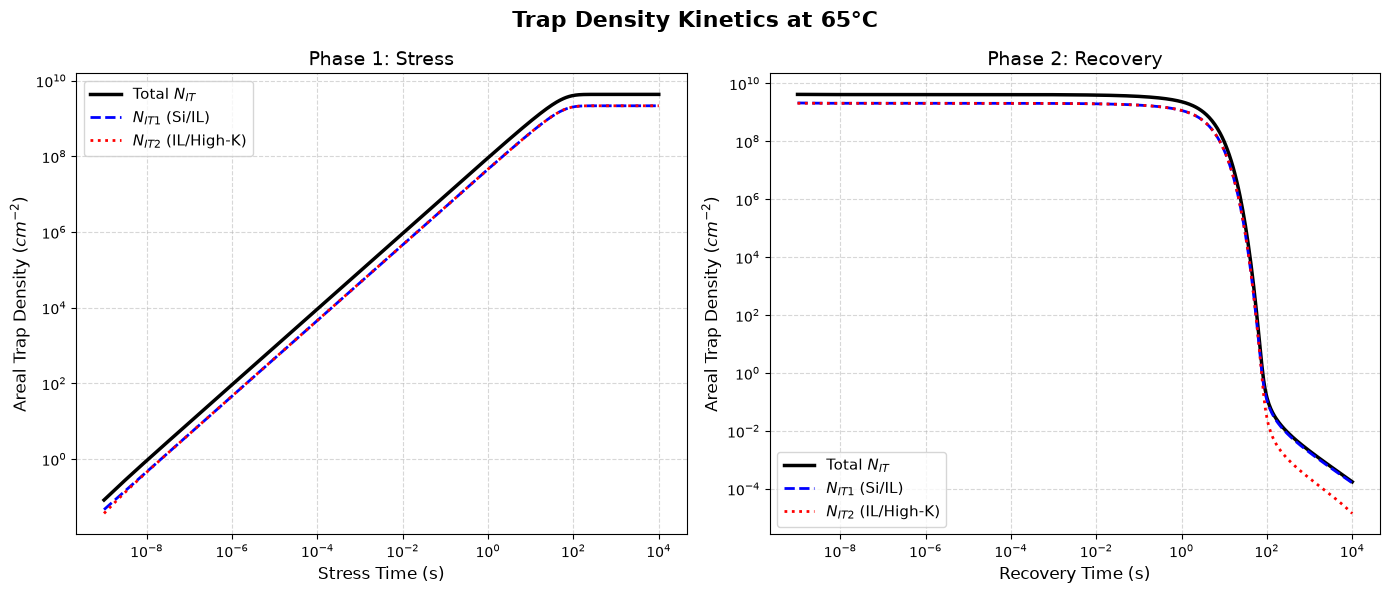

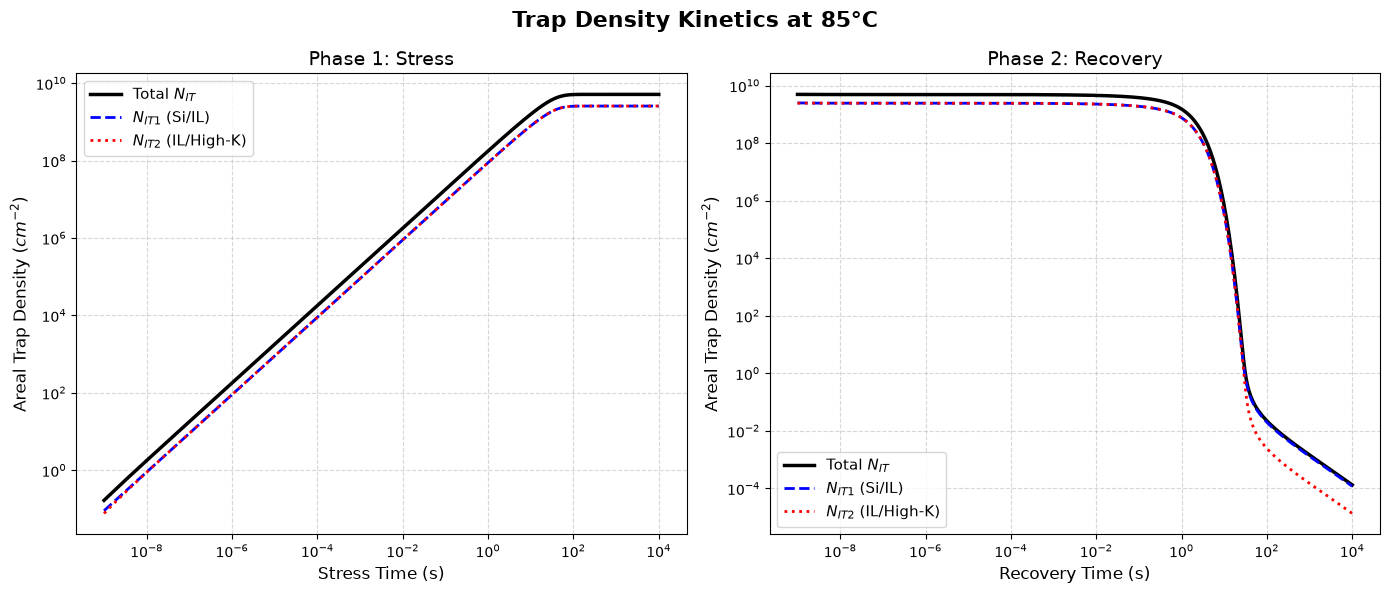

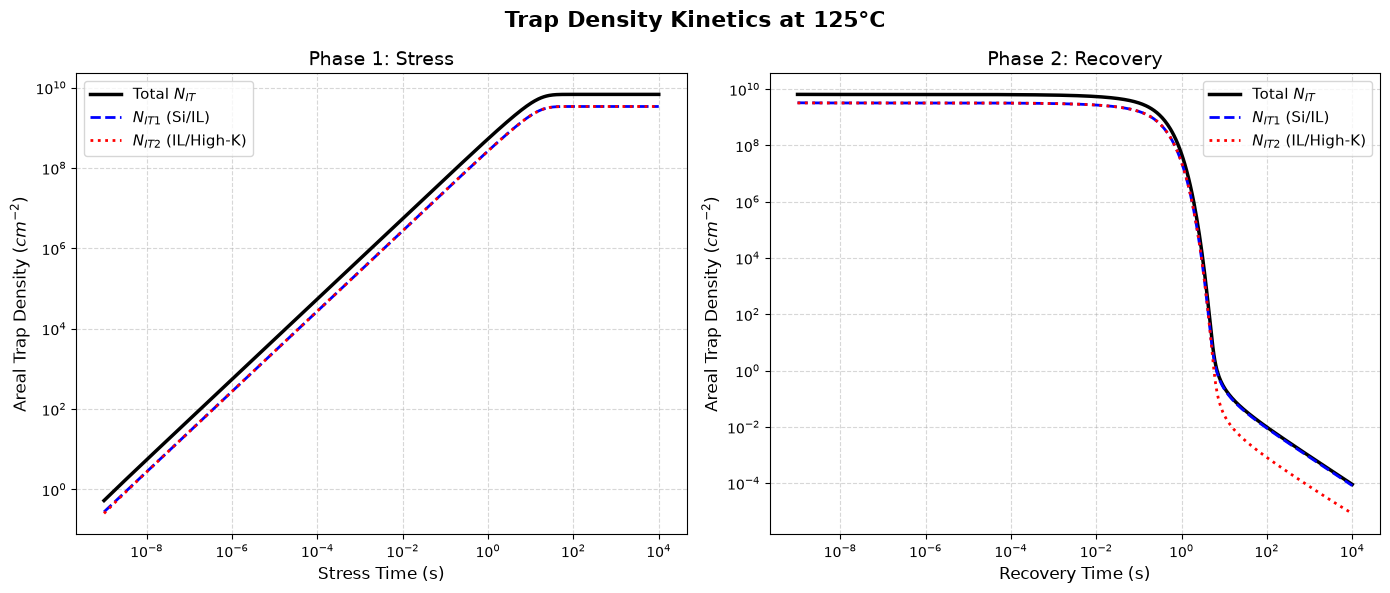

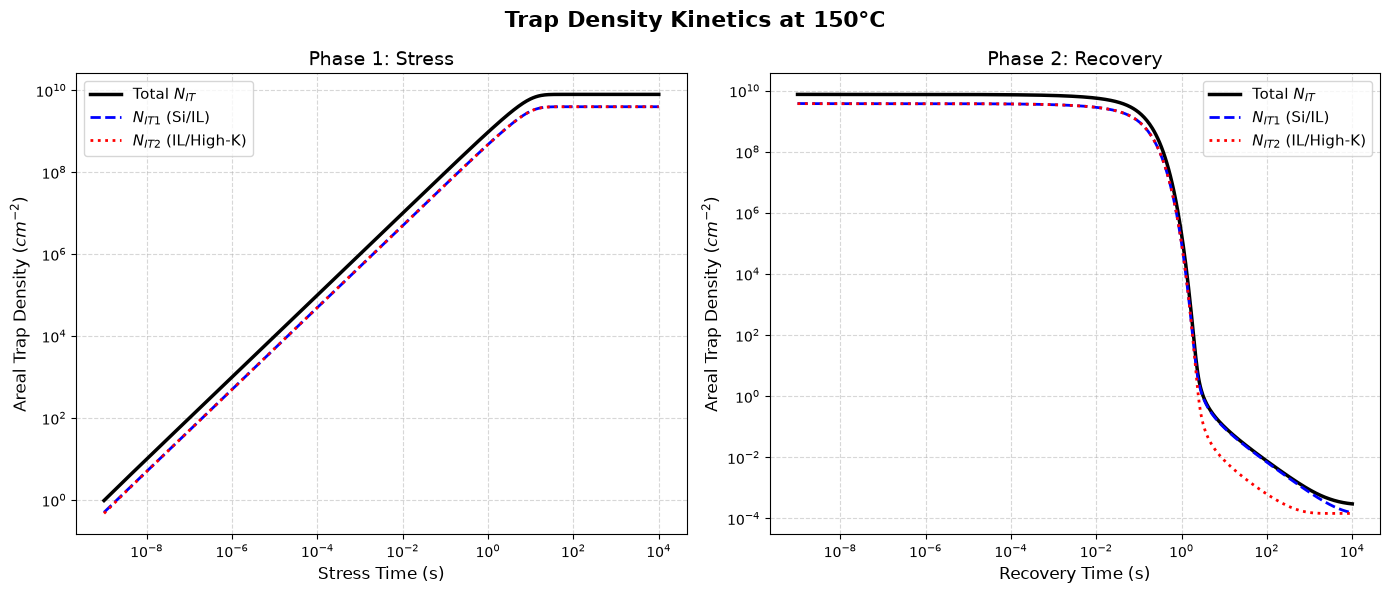

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# CONFIGURATION
# ====================================================================

# Set to the exact 4 temperatures from your C code
temperatures = [65, 85, 125, 150]
file_prefix = "nr_results_"

# ====================================================================
# LOAD DATA
# ====================================================================

data_dict = {}

for T in temperatures:
    filename = f"{file_prefix}{T}C.csv"
    try:
        df = pd.read_csv(filename)

        # Calculate Total Trap Density if not explicitly in the CSV
        if "Total_NIT" not in df.columns:
            df["Total_NIT"] = df["Nit1"] + df["Nit2"]

        # Ensure time is numeric and clean invalid rows
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
        df = df.dropna(subset=["Time", "Nit1", "Nit2"])

        data_dict[T] = df
        print(f"Successfully loaded: {filename}")

    except FileNotFoundError:
        print(f"WARNING: Could not find {filename}. Skipping...")
    except Exception as e:
        print(f"ERROR loading {filename}: {e}")

if not data_dict:
    print("Error: No valid CSV data files found.")
    raise SystemExit


# ====================================================================
# PLOT GENERATION (4 SEPARATE FIGURES)
# ====================================================================

# Loop through each temperature and create an isolated Figure for it
for T in temperatures:
    if T not in data_dict:
        continue

    df = data_dict[T]

    # Create a 1x2 subplot grid (Stress on Left, Recovery on Right)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Trap Density Kinetics at {T}°C", fontsize=16, fontweight='bold')

    # ------------------------------------------------------------
    # PANEL 1: STRESS
    # ------------------------------------------------------------
    stress_df = df[df["Phase"] == "Stress"].sort_values("Time")
    
    if not stress_df.empty:
        valid = (stress_df["Time"] > 0) & (stress_df["Total_NIT"] > 0)
        
        # Plot Total NIT (Thick Solid Black)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Total_NIT"], 
                 label="Total $N_{IT}$", color="black", linewidth=2.5)
        
        # Plot Nit1 (Dashed Blue)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Nit1"], 
                 label="$N_{IT1}$ (Si/IL)", color="blue", linewidth=2.0, linestyle="--")
        
        # Plot Nit2 (Dotted Red)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Nit2"], 
                 label="$N_{IT2}$ (IL/High-K)", color="red", linewidth=2.0, linestyle=":")

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_title("Phase 1: Stress", fontsize=14)
    ax1.set_xlabel("Stress Time (s)", fontsize=12)
    ax1.set_ylabel(r"Areal Trap Density ($cm^{-2}$)", fontsize=12)
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.legend(fontsize=11)

    # ------------------------------------------------------------
    # PANEL 2: RECOVERY
    # ------------------------------------------------------------
    recovery_df = df[df["Phase"] == "Recovery"].sort_values("Time")
    
    if not recovery_df.empty:
        valid = (recovery_df["Time"] > 0) & (recovery_df["Total_NIT"] > 0)
        
        # Plot Total NIT (Thick Solid Black)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Total_NIT"], 
                 label="Total $N_{IT}$", color="black", linewidth=2.5)
        
        # Plot Nit1 (Dashed Blue)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Nit1"], 
                 label="$N_{IT1}$ (Si/IL)", color="blue", linewidth=2.0, linestyle="--")
        
        # Plot Nit2 (Dotted Red)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Nit2"], 
                 label="$N_{IT2}$ (IL/High-K)", color="red", linewidth=2.0, linestyle=":")

    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_title("Phase 2: Recovery", fontsize=14)
    ax2.set_xlabel("Recovery Time (s)", fontsize=12)
    ax2.set_ylabel(r"Areal Trap Density ($cm^{-2}$)", fontsize=12)
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.legend(fontsize=11)

    # Adjust layout so titles and labels don't overlap
    fig.tight_layout()

# ====================================================================
# RENDER ALL 4 FIGURES TO SCREEN
# ====================================================================
plt.show()

Successfully loaded: nr_results_65C.csv
Successfully loaded: nr_results_85C.csv
Successfully loaded: nr_results_125C.csv
Successfully loaded: nr_results_150C.csv


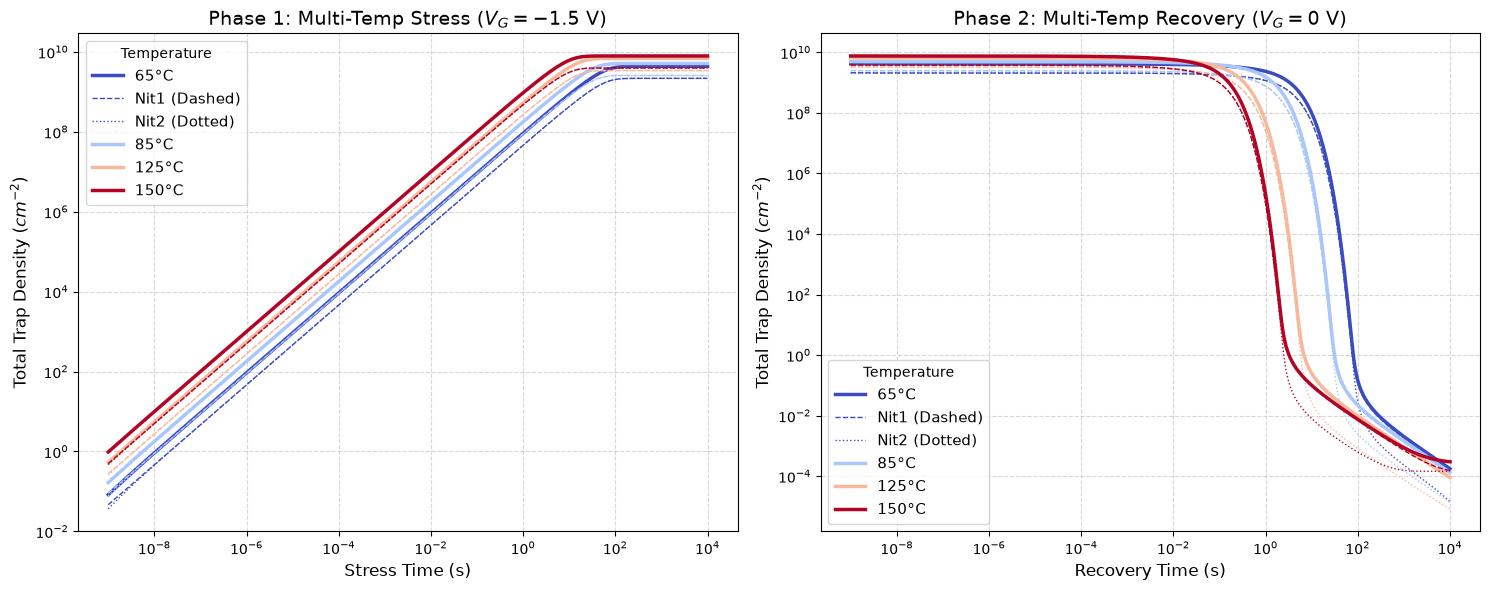

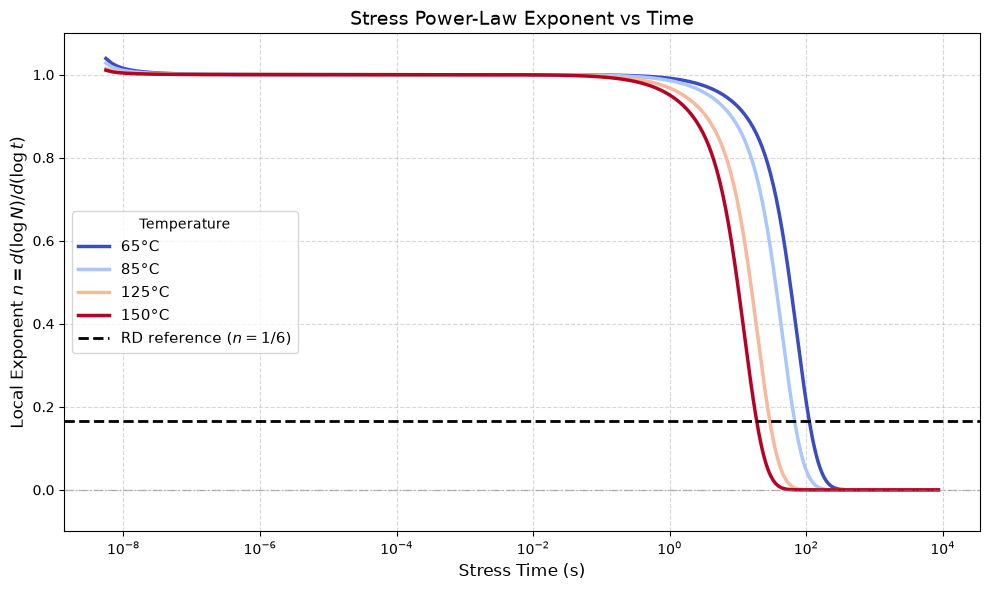

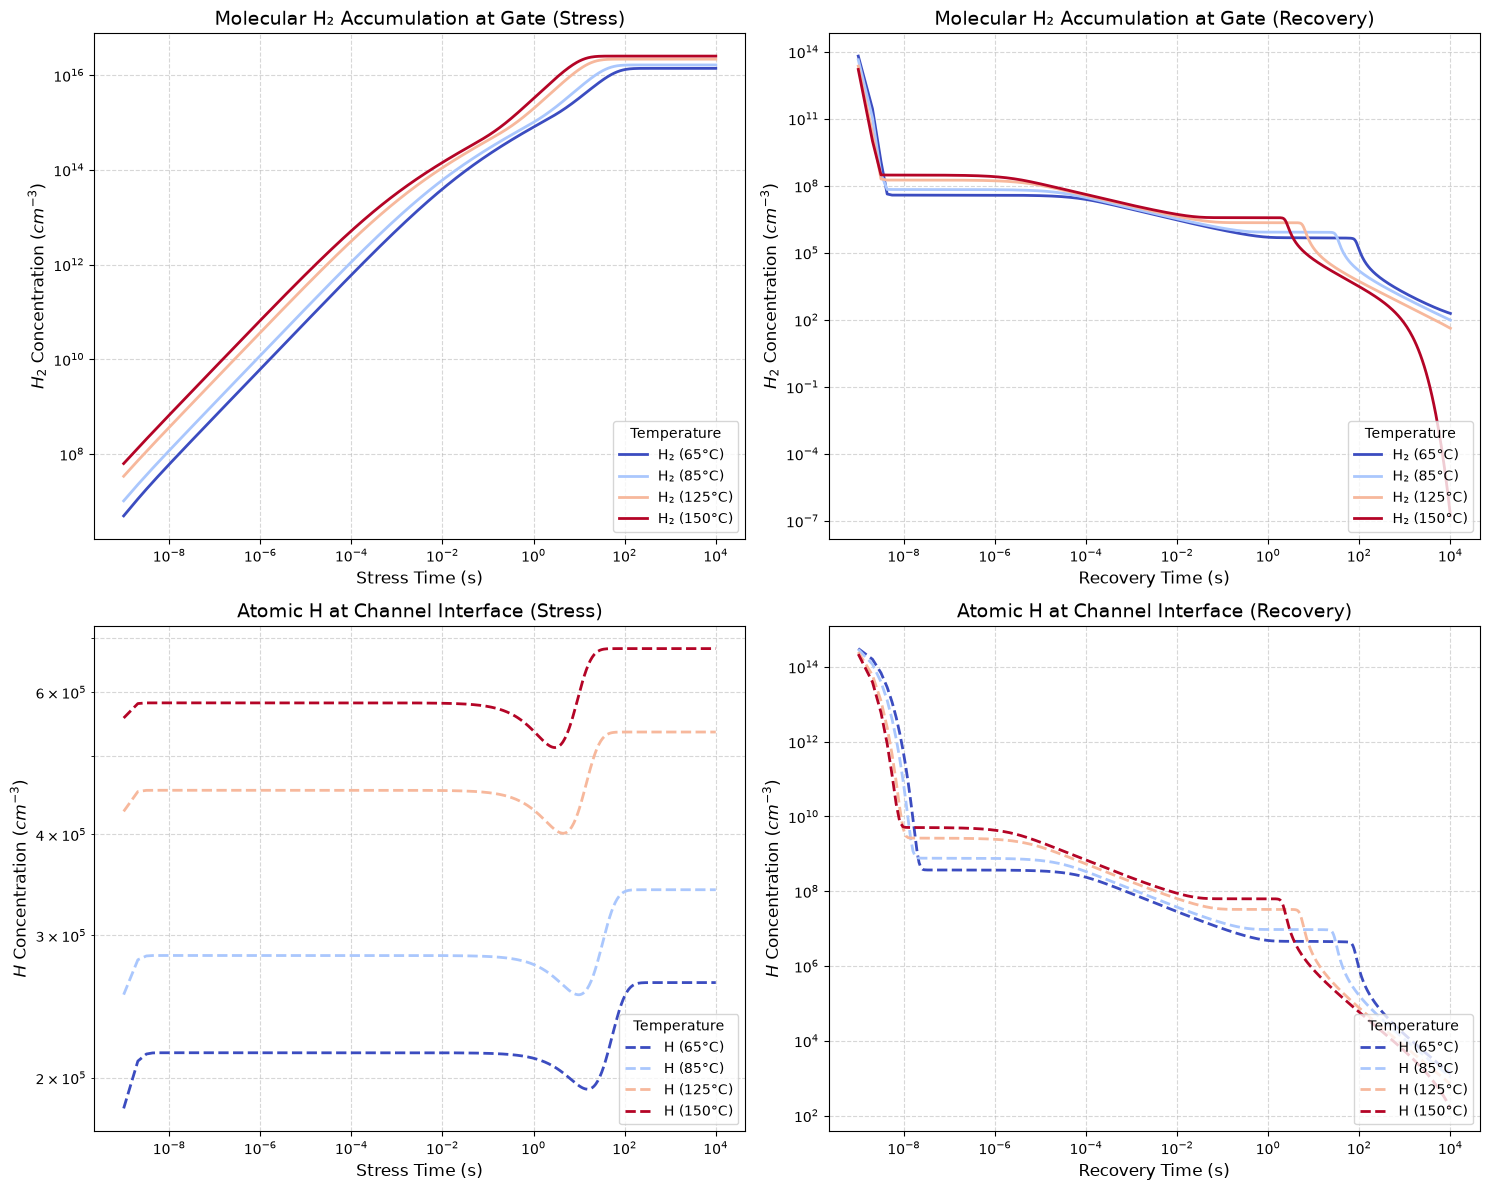


POWER-LAW EXPONENT SUMMARY
 65°C : long-time n = 0.0803 ± 0.1629 (RD reference = 0.1667)
 85°C : long-time n = 0.0320 ± 0.0804 (RD reference = 0.1667)
125°C : long-time n = 0.0018 ± 0.0066 (RD reference = 0.1667)
150°C : long-time n = 0.0001 ± 0.0006 (RD reference = 0.1667)


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ====================================================================
# CONFIGURATION
# ====================================================================

temperatures = [65, 85, 125, 150]

# Your current C code produces:
# nr_results_65C.csv
# nr_results_85C.csv
# nr_results_125C.csv
# nr_results_150C.csv
file_prefix = "nr_results_"

# Window size for local power-law fitting.
# Must be an odd number.
POWERLAW_WINDOW = 9

# ====================================================================
# LOAD DATA
# ====================================================================

data_dict = {}

for T in temperatures:

    filename = f"{file_prefix}{T}C.csv"

    try:
        df = pd.read_csv(filename)

        # Total trap density
        if "Total_NIT" not in df.columns:
            df["Total_NIT"] = df["Nit1"] + df["Nit2"]

        # Make sure time is numeric
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

        # Remove invalid rows
        df = df.dropna(subset=["Time", "Nit1", "Nit2"])

        data_dict[T] = df

        print(f"Successfully loaded: {filename}")

    except FileNotFoundError:
        print(f"WARNING: Could not find {filename}. Skipping...")

    except Exception as e:
        print(f"ERROR loading {filename}: {e}")


if not data_dict:
    print("Error: No data files found.")
    raise SystemExit


# ====================================================================
# COLORS
# ====================================================================

colors = cm.coolwarm(
    np.linspace(0, 1, len(temperatures))
)


# ====================================================================
# HELPER FUNCTION
# LOCAL POWER-LAW EXPONENT
#
# N(t) ~ t^n
#
# Therefore:
#
# log10(N) = n log10(t) + constant
#
# n = slope of log10(N) vs log10(t)
# ====================================================================

def calculate_local_exponent(time, density, window=9):

    time = np.asarray(time, dtype=float)
    density = np.asarray(density, dtype=float)

    # Only positive values can be placed on log scale
    valid = (
        np.isfinite(time)
        & np.isfinite(density)
        & (time > 0)
        & (density > 0)
    )

    time = time[valid]
    density = density[valid]

    if len(time) < window:
        return np.array([]), np.array([])

    # Sort by time
    order = np.argsort(time)

    time = time[order]
    density = density[order]

    log_t = np.log10(time)
    log_N = np.log10(density)

    t_local = []
    n_local = []

    half = window // 2

    for i in range(half, len(time) - half):

        x = log_t[i-half:i+half+1]
        y = log_N[i-half:i+half+1]

        # Linear fit:
        #
        # log10(N) = n*log10(t) + intercept
        #
        slope, intercept = np.polyfit(x, y, 1)

        t_local.append(time[i])
        n_local.append(slope)

    return np.asarray(t_local), np.asarray(n_local)


# ====================================================================
# PLOT 1
# STRESS + RECOVERY TRAP KINETICS
# ====================================================================

fig1, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    df = data_dict[T]

    # ------------------------------------------------------------
    # STRESS
    # ------------------------------------------------------------

    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if not stress_df.empty:

        valid = (
            (stress_df["Time"] > 0)
            & (stress_df["Total_NIT"] > 0)
        )

        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Total_NIT"],
            label=f"{T}°C",
            color=colors[i],
            linewidth=2.5
        )

        # Added: Thin dashed line for Nit1
        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Nit1"],
            label="Nit1 (Dashed)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle="--"
        )

        # Added: Thin dotted line for Nit2
        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Nit2"],
            label="Nit2 (Dotted)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle=":"
        )

    # ------------------------------------------------------------
    # RECOVERY
    # ------------------------------------------------------------

    recovery_df = (
        df[df["Phase"] == "Recovery"]
        .sort_values("Time")
    )

    if not recovery_df.empty:

        valid = (
            (recovery_df["Time"] > 0)
            & (recovery_df["Total_NIT"] > 0)
        )

        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Total_NIT"],
            label=f"{T}°C",
            color=colors[i],
            linewidth=2.5
        )

        # Added: Thin dashed line for Nit1
        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Nit1"],
            label="Nit1 (Dashed)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle="--"
        )

        # Added: Thin dotted line for Nit2
        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Nit2"],
            label="Nit2 (Dotted)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle=":"
        )


# ====================================================================
# STRESS AXIS
# ====================================================================

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_title(
    r"Phase 1: Multi-Temp Stress ($V_G=-1.5$ V)",
    fontsize=14
)

ax1.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax1.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax1.legend(
    title="Temperature",
    fontsize=11
)


# ====================================================================
# RECOVERY AXIS
# ====================================================================

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_title(
    r"Phase 2: Multi-Temp Recovery ($V_G=0$ V)",
    fontsize=14
)

ax2.set_xlabel(
    "Recovery Time (s)",
    fontsize=12
)

ax2.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax2.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax2.legend(
    title="Temperature",
    fontsize=11
)

fig1.tight_layout()


# ====================================================================
# PLOT 2
# LOCAL POWER-LAW EXPONENT
#
# N(t) ~ t^n
#
# n(t) = d(log N) / d(log t)
#
# We estimate this using a local linear regression rather than
# taking point-to-point numerical differences.
# ====================================================================

fig2, ax3 = plt.subplots(
    figsize=(10, 6)
)


for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    stress_df = (
        data_dict[T]
        [data_dict[T]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if stress_df.empty:
        continue

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(t_mid) == 0:
        continue

    ax3.plot(
        t_mid,
        n_local,
        label=f"{T}°C",
        color=colors[i],
        linewidth=2.5
    )


# ====================================================================
# REFERENCE LINES
# ====================================================================

# RD long-time reference
ax3.axhline(
    1.0 / 6.0,
    linestyle="--",
    linewidth=2,
    color="black",
    label=r"RD reference ($n=1/6$)"
)

# Zero exponent
ax3.axhline(
    0.0,
    linestyle="-.",
    linewidth=1,
    color="grey",
    alpha=0.5
)


# ====================================================================
# POWER-LAW FORMATTING
# ====================================================================

ax3.set_xscale("log")

ax3.set_title(
    "Stress Power-Law Exponent vs Time",
    fontsize=14
)

ax3.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax3.set_ylabel(
    r"Local Exponent $n=d(\log N)/d(\log t)$",
    fontsize=12
)

ax3.set_ylim(
    -0.1,
    1.1
)

ax3.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax3.legend(
    title="Temperature",
    fontsize=11
)

fig2.tight_layout()


# ====================================================================
# PLOT 3: HYDROGEN DYNAMICS (UPDATED FOR RECOVERY)
# ====================================================================

# Create a 2x2 grid for H2 (Stress/Recovery) and Atomic H (Stress/Recovery)
fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12))
ax4_stress, ax4_recov = axes3[0, 0], axes3[0, 1]
ax5_stress, ax5_recov = axes3[1, 0], axes3[1, 1]

for i, T in enumerate(temperatures):

    if T not in data_dict:
        continue

    df = data_dict[T]

    # ------------------------------------------------------------
    # STRESS
    # ------------------------------------------------------------
    stress_df = df[df["Phase"] == "Stress"].sort_values("Time")

    if not stress_df.empty:
        # MOLECULAR H2 (STRESS)
        valid_H2 = (stress_df["Time"] > 0) & (stress_df["Mol_H2"] > 1e-10)
        ax4_stress.plot(stress_df.loc[valid_H2, "Time"], stress_df.loc[valid_H2, "Mol_H2"],
                        label=f"H₂ ({T}°C)", color=colors[i], linewidth=2)

        # ATOMIC H (STRESS)
        valid_H0 = (stress_df["Time"] > 0) & (stress_df["Atomic_H0"] > 1e-10)
        ax5_stress.plot(stress_df.loc[valid_H0, "Time"], stress_df.loc[valid_H0, "Atomic_H0"],
                        label=f"H ({T}°C)", color=colors[i], linestyle="--", linewidth=2)

    # ------------------------------------------------------------
    # RECOVERY (ADDED)
    # ------------------------------------------------------------
    recovery_df = df[df["Phase"] == "Recovery"].sort_values("Time")

    if not recovery_df.empty:
        # MOLECULAR H2 (RECOVERY)
        valid_H2_r = (recovery_df["Time"] > 0) & (recovery_df["Mol_H2"] > 1e-10)
        ax4_recov.plot(recovery_df.loc[valid_H2_r, "Time"], recovery_df.loc[valid_H2_r, "Mol_H2"],
                       label=f"H₂ ({T}°C)", color=colors[i], linewidth=2)

        # ATOMIC H (RECOVERY)
        valid_H0_r = (recovery_df["Time"] > 0) & (recovery_df["Atomic_H0"] > 1e-10)
        ax5_recov.plot(recovery_df.loc[valid_H0_r, "Time"], recovery_df.loc[valid_H0_r, "Atomic_H0"],
                       label=f"H ({T}°C)", color=colors[i], linestyle="--", linewidth=2)

# ====================================================================
# FORMAT PLOT 3 AXES
# ====================================================================

for ax in [ax4_stress, ax4_recov, ax5_stress, ax5_recov]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(title="Temperature", fontsize=10, loc="lower right")

# H2 Specific Formatting
ax4_stress.set_title("Molecular H₂ Accumulation at Gate (Stress)", fontsize=14)
ax4_recov.set_title("Molecular H₂ Accumulation at Gate (Recovery)", fontsize=14)
ax4_stress.set_xlabel("Stress Time (s)", fontsize=12)
ax4_recov.set_xlabel("Recovery Time (s)", fontsize=12)
ax4_stress.set_ylabel(r"$H_2$ Concentration ($cm^{-3}$)", fontsize=12)
ax4_recov.set_ylabel(r"$H_2$ Concentration ($cm^{-3}$)", fontsize=12)

# Atomic H Specific Formatting
ax5_stress.set_title("Atomic H at Channel Interface (Stress)", fontsize=14)
ax5_recov.set_title("Atomic H at Channel Interface (Recovery)", fontsize=14)
ax5_stress.set_xlabel("Stress Time (s)", fontsize=12)
ax5_recov.set_xlabel("Recovery Time (s)", fontsize=12)
ax5_stress.set_ylabel(r"$H$ Concentration ($cm^{-3}$)", fontsize=12)
ax5_recov.set_ylabel(r"$H$ Concentration ($cm^{-3}$)", fontsize=12)

fig3.tight_layout()


# ====================================================================
# SHOW ALL FIGURES
# ====================================================================

plt.show()


# ====================================================================
# PRINT A QUICK NUMERICAL SUMMARY OF THE POWER-LAW REGION
# ====================================================================

print("\n============================================================")
print("POWER-LAW EXPONENT SUMMARY")
print("============================================================")

for T in temperatures:

    if T not in data_dict:
        continue

    stress_df = (
        data_dict[T]
        [data_dict[T]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(n_local) == 0:
        print(f"{T}°C : insufficient data")
        continue

    # Use the final 20% of the available exponent points
    # as a simple long-time estimate.
    start = int(0.8 * len(n_local))

    n_long = n_local[start:]

    mean_n = np.mean(n_long)
    std_n = np.std(n_long)

    print(
        f"{T:3d}°C : "
        f"long-time n = {mean_n:.4f} ± {std_n:.4f} "
        f"(RD reference = {1/6:.4f})"
    )

print("============================================================")

Successfully loaded: nr_results_1.2V.csv
Successfully loaded: nr_results_1.5V.csv
Successfully loaded: nr_results_1.8V.csv
Successfully loaded: nr_results_2.0V.csv


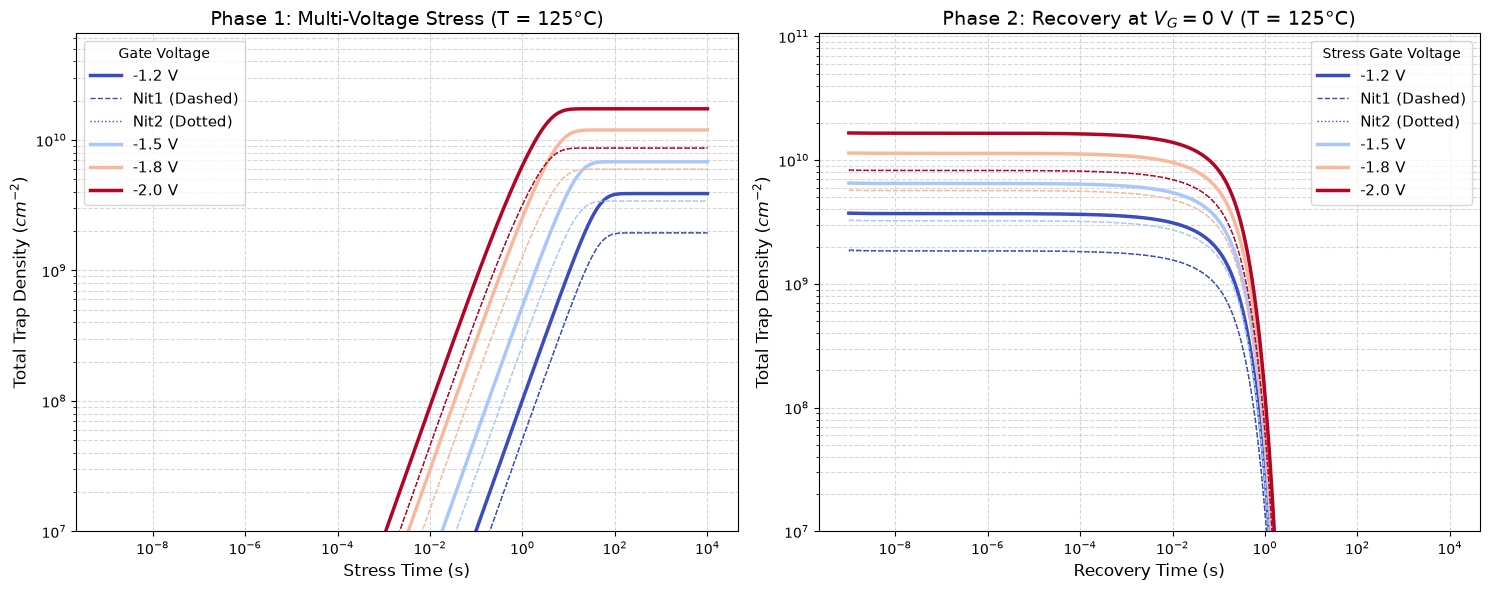

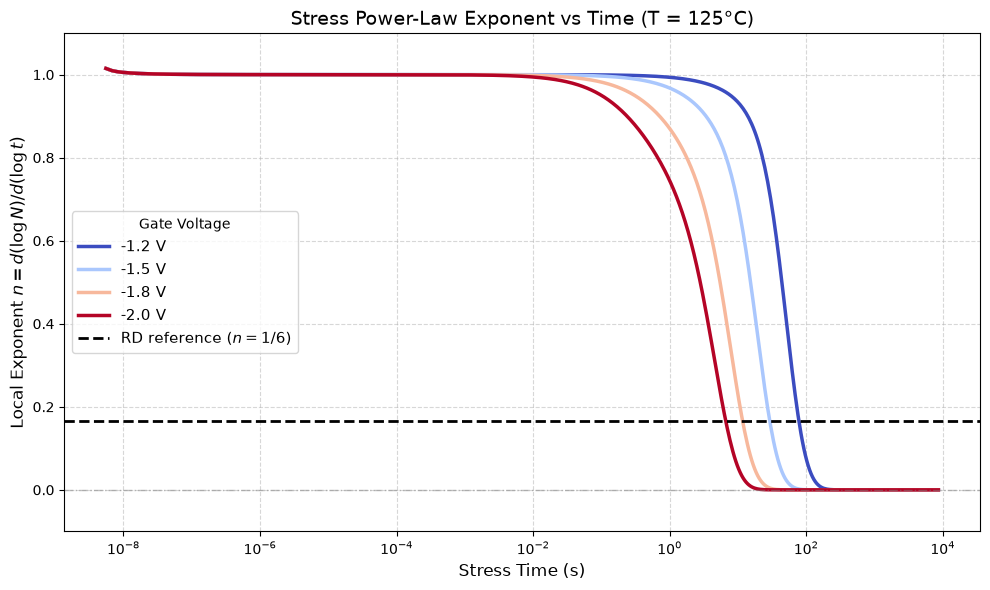

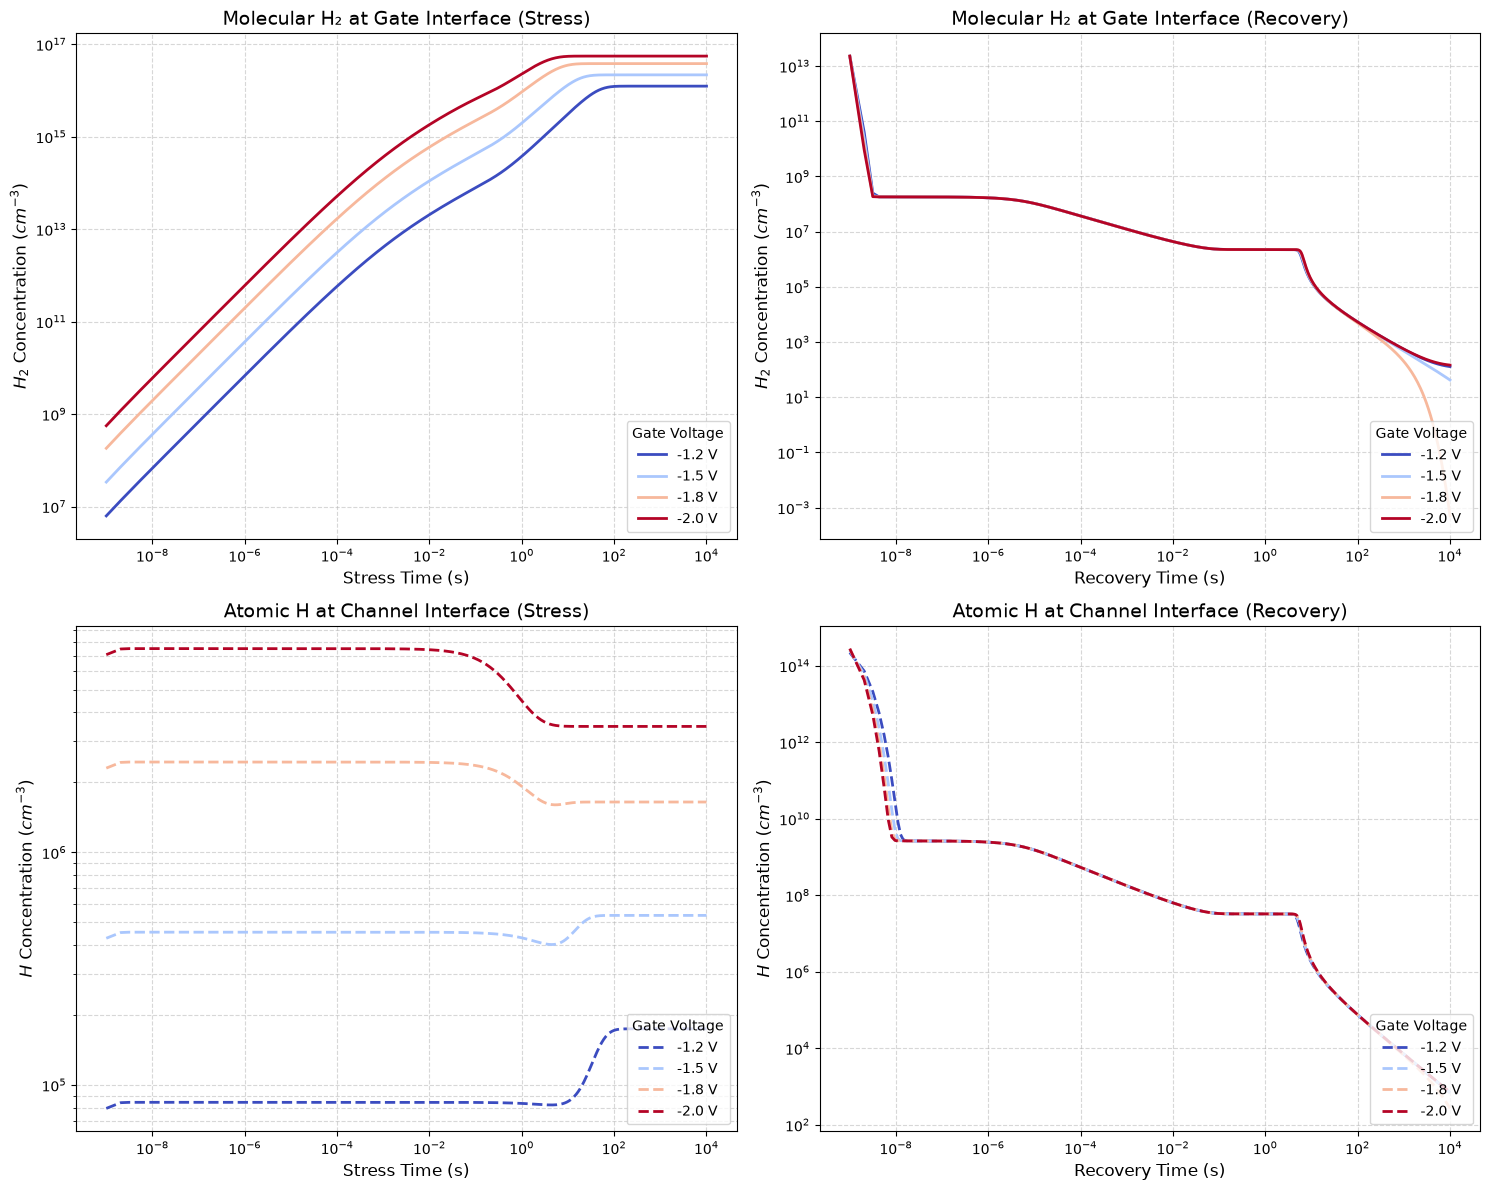

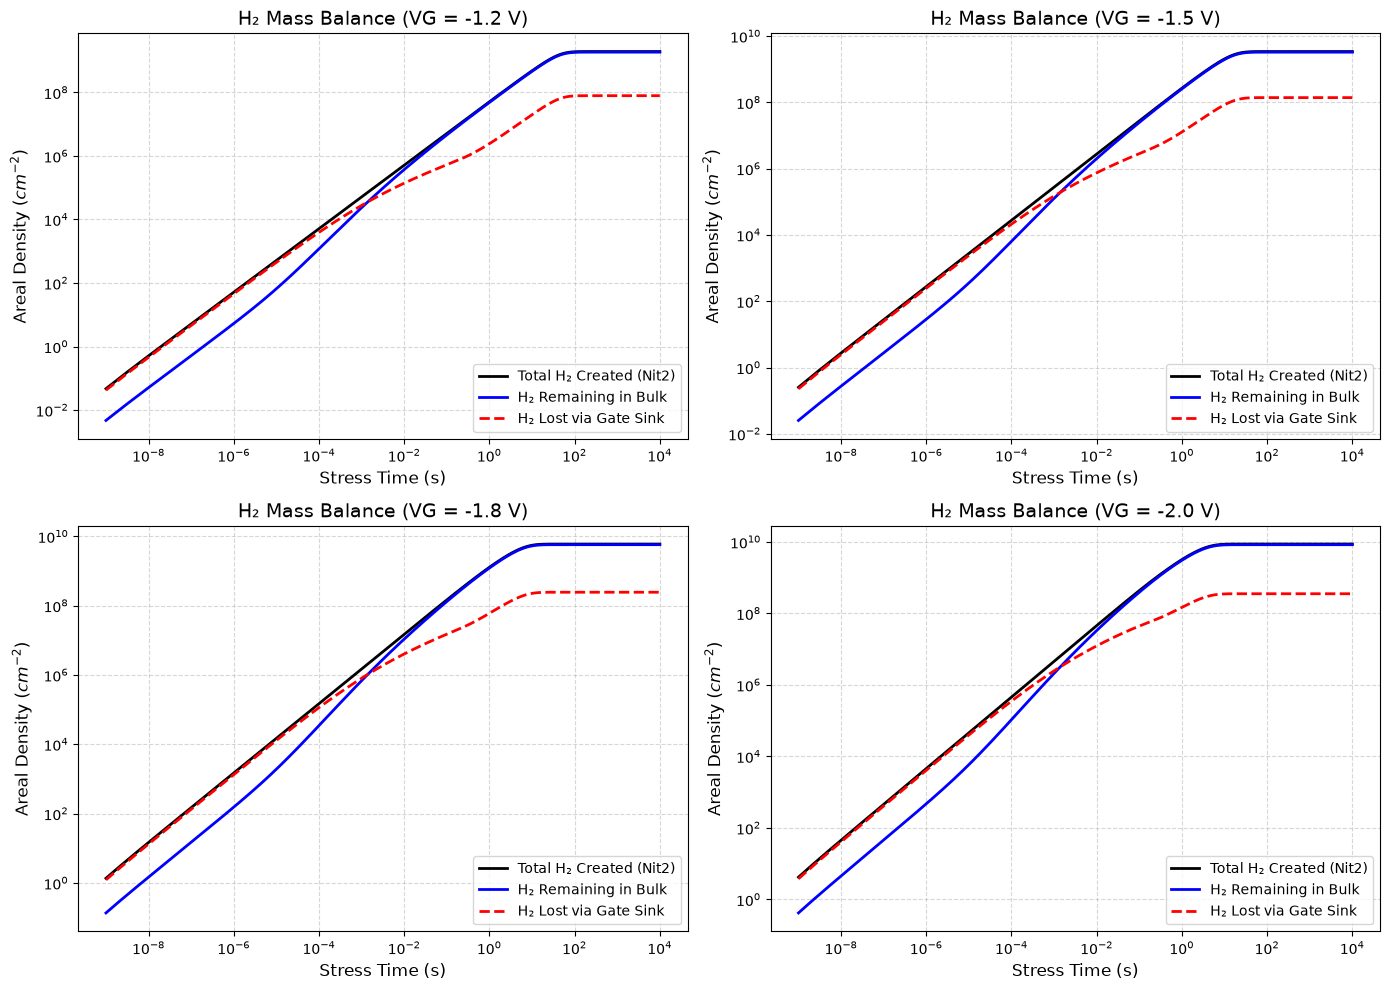


POWER-LAW EXPONENT SUMMARY
-1.2  V : long-time n = 0.0452 ± 0.1096 (RD reference = 0.1667)
-1.5  V : long-time n = 0.0018 ± 0.0066 (RD reference = 0.1667)
-1.8  V : long-time n = 0.0000 ± 0.0000 (RD reference = 0.1667)
-2.0  V : long-time n = 0.0000 ± 0.0000 (RD reference = 0.1667)


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ====================================================================
# CONFIGURATION
# ====================================================================

# Now sweeping across Gate Voltages instead of Temperatures
voltages = [1.2, 1.5, 1.8, 2.0]

# Your C code now produces:
# nr_results_1.2V.csv
# nr_results_1.5V.csv
# nr_results_1.8V.csv
# nr_results_2.0V.csv
file_prefix = "nr_results_"

# Window size for local power-law fitting.
# Must be an odd number.
POWERLAW_WINDOW = 9

# ====================================================================
# LOAD DATA
# ====================================================================

data_dict = {}

for V in voltages:

    filename = f"{file_prefix}{V}V.csv"

    try:
        df = pd.read_csv(filename)

        # Total trap density
        if "Total_NIT" not in df.columns:
            df["Total_NIT"] = df["Nit1"] + df["Nit2"]

        # Make sure time is numeric
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

        # Remove invalid rows
        df = df.dropna(subset=["Time", "Nit1", "Nit2"])

        data_dict[V] = df

        print(f"Successfully loaded: {filename}")

    except FileNotFoundError:
        print(f"WARNING: Could not find {filename}. Skipping...")

    except Exception as e:
        print(f"ERROR loading {filename}: {e}")


if not data_dict:
    print("Error: No data files found.")
    raise SystemExit


# ====================================================================
# COLORS
# ====================================================================

colors = cm.coolwarm(
    np.linspace(0, 1, len(voltages))
)


# ====================================================================
# HELPER FUNCTION
# LOCAL POWER-LAW EXPONENT
# ====================================================================

def calculate_local_exponent(time, density, window=9):

    time = np.asarray(time, dtype=float)
    density = np.asarray(density, dtype=float)

    # Only positive values can be placed on log scale
    valid = (
        np.isfinite(time)
        & np.isfinite(density)
        & (time > 0)
        & (density > 0)
    )

    time = time[valid]
    density = density[valid]

    if len(time) < window:
        return np.array([]), np.array([])

    # Sort by time
    order = np.argsort(time)

    time = time[order]
    density = density[order]

    log_t = np.log10(time)
    log_N = np.log10(density)

    t_local = []
    n_local = []

    half = window // 2

    for i in range(half, len(time) - half):

        x = log_t[i-half:i+half+1]
        y = log_N[i-half:i+half+1]

        # Linear fit
        slope, intercept = np.polyfit(x, y, 1)

        t_local.append(time[i])
        n_local.append(slope)

    return np.asarray(t_local), np.asarray(n_local)


# ====================================================================
# PLOT 1
# STRESS + RECOVERY TRAP KINETICS
# ====================================================================

fig1, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


for i, V in enumerate(voltages):

    if V not in data_dict:
        continue

    df = data_dict[V]

    # ------------------------------------------------------------
    # STRESS
    # ------------------------------------------------------------

    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if not stress_df.empty:

        valid = (
            (stress_df["Time"] > 0)
            & (stress_df["Total_NIT"] > 0)
        )

        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Total_NIT"],
            label=f"-{V} V",
            color=colors[i],
            linewidth=2.5
        )

        # Thin dashed line for Nit1
        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Nit1"],
            label="Nit1 (Dashed)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle="--"
        )

        # Thin dotted line for Nit2
        ax1.plot(
            stress_df.loc[valid, "Time"],
            stress_df.loc[valid, "Nit2"],
            label="Nit2 (Dotted)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle=":"
        )

    # ------------------------------------------------------------
    # RECOVERY
    # ------------------------------------------------------------

    recovery_df = (
        df[df["Phase"] == "Recovery"]
        .sort_values("Time")
    )

    if not recovery_df.empty:

        valid = (
            (recovery_df["Time"] > 0)
            & (recovery_df["Total_NIT"] > 0)
        )

        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Total_NIT"],
            label=f"-{V} V",
            color=colors[i],
            linewidth=2.5
        )

        # Thin dashed line for Nit1
        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Nit1"],
            label="Nit1 (Dashed)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle="--"
        )

        # Thin dotted line for Nit2
        ax2.plot(
            recovery_df.loc[valid, "Time"],
            recovery_df.loc[valid, "Nit2"],
            label="Nit2 (Dotted)" if i == 0 else None,
            color=colors[i],
            linewidth=1.0,
            linestyle=":"
        )


# ====================================================================
# STRESS AXIS
# ====================================================================

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(bottom=1e7) # Hides numerical zero noise

ax1.set_title(
    r"Phase 1: Multi-Voltage Stress (T = 125°C)",
    fontsize=14
)

ax1.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax1.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax1.legend(
    title="Gate Voltage",
    fontsize=11
)


# ====================================================================
# RECOVERY AXIS
# ====================================================================

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_ylim(bottom=1e7) # Hides numerical zero noise

ax2.set_title(
    r"Phase 2: Recovery at $V_G = 0$ V (T = 125°C)",
    fontsize=14
)

ax2.set_xlabel(
    "Recovery Time (s)",
    fontsize=12
)

ax2.set_ylabel(
    r"Total Trap Density ($cm^{-2}$)",
    fontsize=12
)

ax2.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax2.legend(
    title="Stress Gate Voltage",
    fontsize=11
)

fig1.tight_layout()


# ====================================================================
# PLOT 2
# LOCAL POWER-LAW EXPONENT
# ====================================================================

fig2, ax3 = plt.subplots(
    figsize=(10, 6)
)


for i, V in enumerate(voltages):

    if V not in data_dict:
        continue

    stress_df = (
        data_dict[V]
        [data_dict[V]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    if stress_df.empty:
        continue

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(t_mid) == 0:
        continue

    ax3.plot(
        t_mid,
        n_local,
        label=f"-{V} V",
        color=colors[i],
        linewidth=2.5
    )


# ====================================================================
# REFERENCE LINES
# ====================================================================

ax3.axhline(
    1.0 / 6.0,
    linestyle="--",
    linewidth=2,
    color="black",
    label=r"RD reference ($n=1/6$)"
)

ax3.axhline(
    0.0,
    linestyle="-.",
    linewidth=1,
    color="grey",
    alpha=0.5
)


# ====================================================================
# POWER-LAW FORMATTING
# ====================================================================

ax3.set_xscale("log")

ax3.set_title(
    "Stress Power-Law Exponent vs Time (T = 125°C)",
    fontsize=14
)

ax3.set_xlabel(
    "Stress Time (s)",
    fontsize=12
)

ax3.set_ylabel(
    r"Local Exponent $n=d(\log N)/d(\log t)$",
    fontsize=12
)

ax3.set_ylim(
    -0.1,
    1.1
)

ax3.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5
)

ax3.legend(
    title="Gate Voltage",
    fontsize=11
)

fig2.tight_layout()


# ====================================================================
# PLOT 3: HYDROGEN DYNAMICS (UPDATED FOR RECOVERY)
# ====================================================================

fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12))
ax4_stress, ax4_recov = axes3[0, 0], axes3[0, 1]
ax5_stress, ax5_recov = axes3[1, 0], axes3[1, 1]

for i, V in enumerate(voltages):

    if V not in data_dict:
        continue

    df = data_dict[V]

    # ------------------------------------------------------------
    # STRESS
    # ------------------------------------------------------------
    stress_df = df[df["Phase"] == "Stress"].sort_values("Time")

    if not stress_df.empty:
        # MOLECULAR H2 (STRESS)
        valid_H2 = (stress_df["Time"] > 0) & (stress_df["Mol_H2"] > 1e-10)
        ax4_stress.plot(stress_df.loc[valid_H2, "Time"], stress_df.loc[valid_H2, "Mol_H2"],
                        label=f"-{V} V", color=colors[i], linewidth=2)

        # ATOMIC H (STRESS)
        valid_H0 = (stress_df["Time"] > 0) & (stress_df["Atomic_H0"] > 1e-10)
        ax5_stress.plot(stress_df.loc[valid_H0, "Time"], stress_df.loc[valid_H0, "Atomic_H0"],
                        label=f"-{V} V", color=colors[i], linestyle="--", linewidth=2)

    # ------------------------------------------------------------
    # RECOVERY 
    # ------------------------------------------------------------
    recovery_df = df[df["Phase"] == "Recovery"].sort_values("Time")

    if not recovery_df.empty:
        # MOLECULAR H2 (RECOVERY)
        valid_H2_r = (recovery_df["Time"] > 0) & (recovery_df["Mol_H2"] > 1e-10)
        ax4_recov.plot(recovery_df.loc[valid_H2_r, "Time"], recovery_df.loc[valid_H2_r, "Mol_H2"],
                       label=f"-{V} V", color=colors[i], linewidth=2)

        # ATOMIC H (RECOVERY)
        valid_H0_r = (recovery_df["Time"] > 0) & (recovery_df["Atomic_H0"] > 1e-10)
        ax5_recov.plot(recovery_df.loc[valid_H0_r, "Time"], recovery_df.loc[valid_H0_r, "Atomic_H0"],
                       label=f"-{V} V", color=colors[i], linestyle="--", linewidth=2)

# ====================================================================
# FORMAT PLOT 3 AXES
# ====================================================================

for ax in [ax4_stress, ax4_recov, ax5_stress, ax5_recov]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(title="Gate Voltage", fontsize=10, loc="lower right")

ax4_stress.set_title("Molecular H₂ at Gate Interface (Stress)", fontsize=14)
ax4_recov.set_title("Molecular H₂ at Gate Interface (Recovery)", fontsize=14)
ax4_stress.set_xlabel("Stress Time (s)", fontsize=12)
ax4_recov.set_xlabel("Recovery Time (s)", fontsize=12)
ax4_stress.set_ylabel(r"$H_2$ Concentration ($cm^{-3}$)", fontsize=12)
ax4_recov.set_ylabel(r"$H_2$ Concentration ($cm^{-3}$)", fontsize=12)

ax5_stress.set_title("Atomic H at Channel Interface (Stress)", fontsize=14)
ax5_recov.set_title("Atomic H at Channel Interface (Recovery)", fontsize=14)
ax5_stress.set_xlabel("Stress Time (s)", fontsize=12)
ax5_recov.set_xlabel("Recovery Time (s)", fontsize=12)
ax5_stress.set_ylabel(r"$H$ Concentration ($cm^{-3}$)", fontsize=12)
ax5_recov.set_ylabel(r"$H$ Concentration ($cm^{-3}$)", fontsize=12)

fig3.tight_layout()


# ====================================================================
# PLOT 4
# MASS BALANCE
# ====================================================================

fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, V in enumerate(voltages):
    if V not in data_dict:
        continue
        
    df = data_dict[V]
    stress_df = (
        df[df["Phase"] == "Stress"]
        .sort_values("Time")
    )
    
    # Check if mass balance data was exported from C
    if not stress_df.empty and "H2_Remaining" in stress_df.columns and "H2_Lost" in stress_df.columns and "Nit2" in stress_df.columns:
        ax = axes[i]
        
        ax.plot(stress_df["Time"], stress_df["Nit2"], label="Total H₂ Created (Nit2)", color="black", linewidth=2)
        ax.plot(stress_df["Time"], stress_df["H2_Remaining"], label="H₂ Remaining in Bulk", color="blue", linewidth=2)
        ax.plot(stress_df["Time"], stress_df["H2_Lost"], label="H₂ Lost via Gate Sink", color="red", linestyle="--", linewidth=2)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"H₂ Mass Balance (VG = -{V} V)", fontsize=14)
        ax.set_xlabel("Stress Time (s)", fontsize=12)
        ax.set_ylabel(r"Areal Density ($cm^{-2}$)", fontsize=12)
        ax.grid(True, which="both", linestyle="--", alpha=0.5)
        ax.legend(fontsize=10, loc="lower right")

fig4.tight_layout()


# ====================================================================
# SHOW ALL FIGURES
# ====================================================================

plt.show()


# ====================================================================
# PRINT A QUICK NUMERICAL SUMMARY OF THE POWER-LAW REGION
# ====================================================================

print("\n============================================================")
print("POWER-LAW EXPONENT SUMMARY")
print("============================================================")

for V in voltages:

    if V not in data_dict:
        continue

    stress_df = (
        data_dict[V]
        [data_dict[V]["Phase"] == "Stress"]
        .sort_values("Time")
    )

    t_mid, n_local = calculate_local_exponent(
        stress_df["Time"],
        stress_df["Total_NIT"],
        window=POWERLAW_WINDOW
    )

    if len(n_local) == 0:
        print(f"-{V} V : insufficient data")
        continue

    start = int(0.8 * len(n_local))

    n_long = n_local[start:]

    mean_n = np.mean(n_long)
    std_n = np.std(n_long)

    print(
        f"-{V:<4.1f} V : "
        f"long-time n = {mean_n:.4f} ± {std_n:.4f} "
        f"(RD reference = {1/6:.4f})"
    )

print("============================================================")

Successfully loaded: nr_results_1.2V.csv
Successfully loaded: nr_results_1.5V.csv
Successfully loaded: nr_results_1.8V.csv
Successfully loaded: nr_results_2.0V.csv


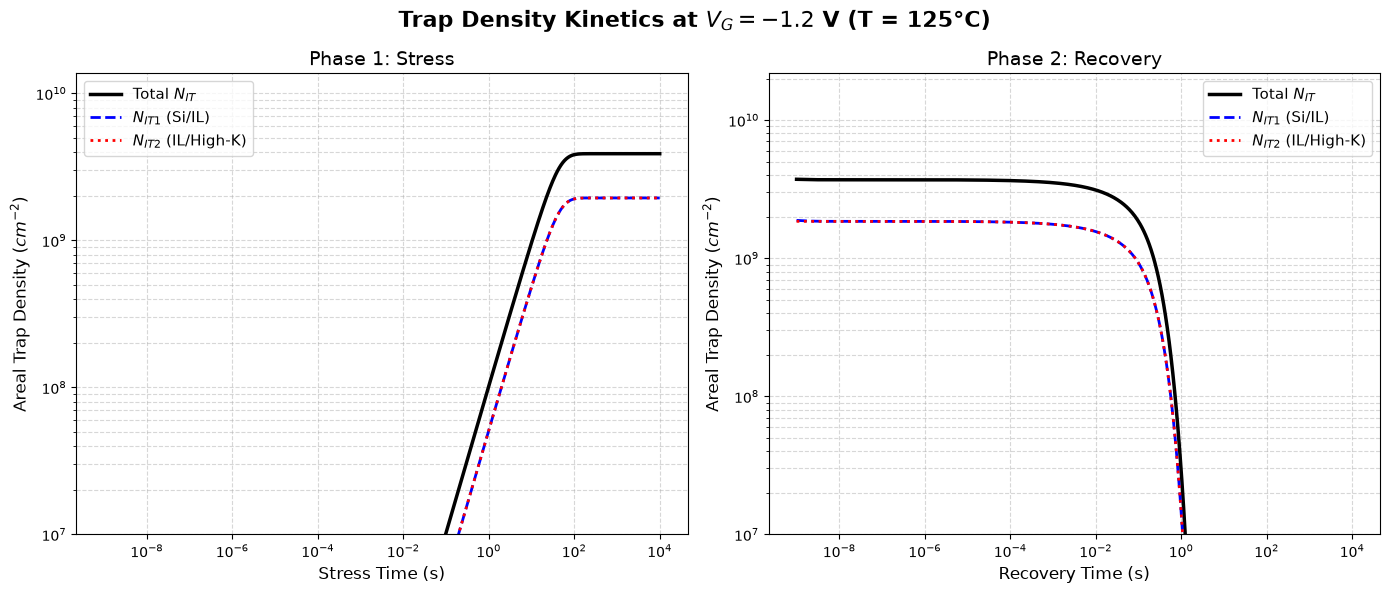

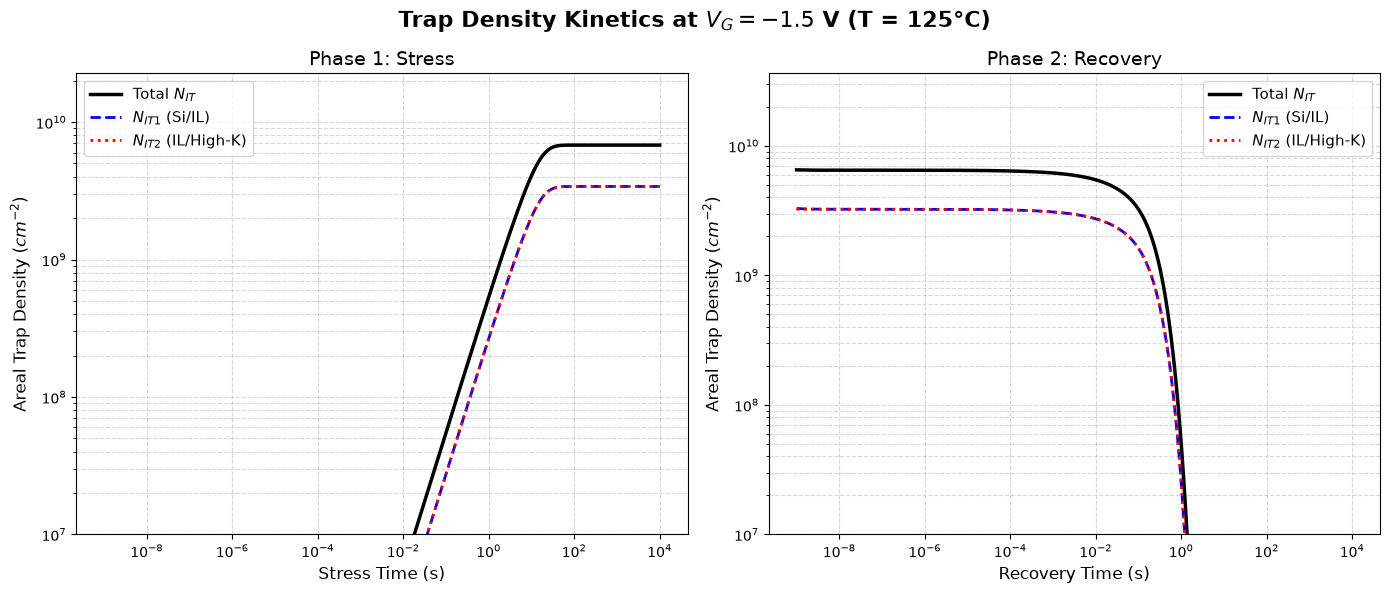

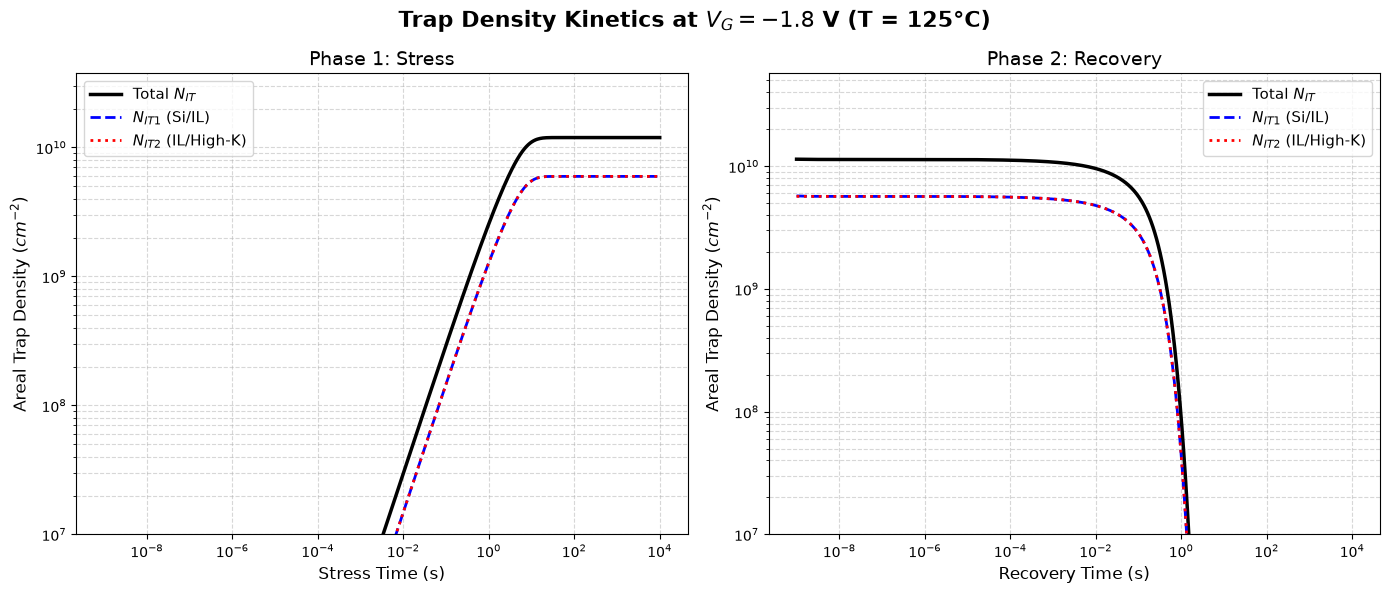

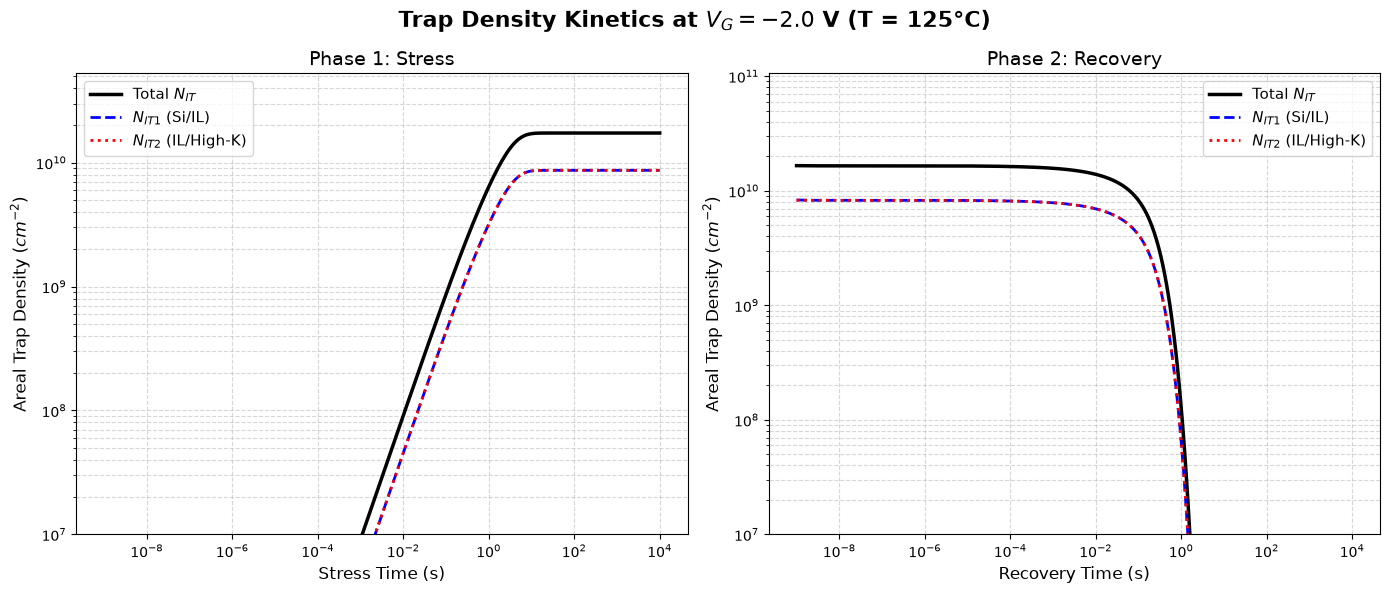

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# CONFIGURATION
# ====================================================================

# Set to the exact 4 voltages from your updated C code
voltages = [1.2, 1.5, 1.8, 2.0]
file_prefix = "nr_results_"

# ====================================================================
# LOAD DATA
# ====================================================================

data_dict = {}

for V in voltages:
    # Look for files like nr_results_1.2V.csv
    filename = f"{file_prefix}{V}V.csv"
    try:
        df = pd.read_csv(filename)

        # Calculate Total Trap Density if not explicitly in the CSV
        if "Total_NIT" not in df.columns:
            df["Total_NIT"] = df["Nit1"] + df["Nit2"]

        # Ensure time is numeric and clean invalid rows
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
        df = df.dropna(subset=["Time", "Nit1", "Nit2"])

        data_dict[V] = df
        print(f"Successfully loaded: {filename}")

    except FileNotFoundError:
        print(f"WARNING: Could not find {filename}. Skipping...")
    except Exception as e:
        print(f"ERROR loading {filename}: {e}")

if not data_dict:
    print("Error: No valid CSV data files found.")
    raise SystemExit


# ====================================================================
# PLOT GENERATION (4 SEPARATE FIGURES)
# ====================================================================

# Loop through each voltage and create an isolated Figure for it
for V in voltages:
    if V not in data_dict:
        continue

    df = data_dict[V]

    # Create a 1x2 subplot grid (Stress on Left, Recovery on Right)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Trap Density Kinetics at $V_G = -{V}$ V (T = 125°C)", fontsize=16, fontweight='bold')

    # ------------------------------------------------------------
    # PANEL 1: STRESS
    # ------------------------------------------------------------
    stress_df = df[df["Phase"] == "Stress"].sort_values("Time")
    
    if not stress_df.empty:
        valid = (stress_df["Time"] > 0) & (stress_df["Total_NIT"] > 0)
        
        # Plot Total NIT (Thick Solid Black)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Total_NIT"], 
                 label="Total $N_{IT}$", color="black", linewidth=2.5)
        
        # Plot Nit1 (Dashed Blue)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Nit1"], 
                 label="$N_{IT1}$ (Si/IL)", color="blue", linewidth=2.0, linestyle="--")
        
        # Plot Nit2 (Dotted Red)
        ax1.plot(stress_df.loc[valid, "Time"], stress_df.loc[valid, "Nit2"], 
                 label="$N_{IT2}$ (IL/High-K)", color="red", linewidth=2.0, linestyle=":")

    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_ylim(bottom=1e7) # Hides numerical zero floating-point noise
    ax1.set_title("Phase 1: Stress", fontsize=14)
    ax1.set_xlabel("Stress Time (s)", fontsize=12)
    ax1.set_ylabel(r"Areal Trap Density ($cm^{-2}$)", fontsize=12)
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.legend(fontsize=11)

    # ------------------------------------------------------------
    # PANEL 2: RECOVERY
    # ------------------------------------------------------------
    recovery_df = df[df["Phase"] == "Recovery"].sort_values("Time")
    
    if not recovery_df.empty:
        valid = (recovery_df["Time"] > 0) & (recovery_df["Total_NIT"] > 0)
        
        # Plot Total NIT (Thick Solid Black)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Total_NIT"], 
                 label="Total $N_{IT}$", color="black", linewidth=2.5)
        
        # Plot Nit1 (Dashed Blue)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Nit1"], 
                 label="$N_{IT1}$ (Si/IL)", color="blue", linewidth=2.0, linestyle="--")
        
        # Plot Nit2 (Dotted Red)
        ax2.plot(recovery_df.loc[valid, "Time"], recovery_df.loc[valid, "Nit2"], 
                 label="$N_{IT2}$ (IL/High-K)", color="red", linewidth=2.0, linestyle=":")

    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_ylim(bottom=1e7) # Hides numerical zero floating-point noise
    ax2.set_title("Phase 2: Recovery", fontsize=14)
    ax2.set_xlabel("Recovery Time (s)", fontsize=12)
    ax2.set_ylabel(r"Areal Trap Density ($cm^{-2}$)", fontsize=12)
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.legend(fontsize=11)

    # Adjust layout so titles and labels don't overlap
    fig.tight_layout()

# ====================================================================
# RENDER ALL 4 FIGURES TO SCREEN
# ====================================================================
plt.show()